## Hello welcome to Aaron's Data analysis
Ultimately here's what I plan on implementing

* [X] Map the ebb and flow of both modes across time. 
  - Histogram displays average ridership by the day of the week
  - Line Chart shows ebb and flow of ridership throughout 2023
* [ ] Generate a gif of the heatmap throughout the day.
* [X] Heatmap of the ridership vs day of week
  - Create a gif for every day of the week
  - Heat map of average HVFVH ridership on Wednesday and Saturday
  - Heat map of average Subway ridership on Wednesday and Sunday
    - Note that the subway is mapped onto the same taxi zones, maybe we do a different more gradient type of heat map for this centered around a radius of our choosing. The problem is that we have alot of zones that don't have subway access.
* [X] Plot the ratio of HVFHV Trips vs transit ridership on a map of NYC
    - Might find areas with high HVFH reliance vs transit
* [ ] Identify regions that are accessible to Public transport, and compare inside and outside those regions
  - We might see higher hvfh reliance outside the zones
  - Might need to do in another bourough
* [ ] Peak Hour comparison
  - HVHF might have higher peak at night
    - Need to get hourly data for HVFHV in July
* [ ] Quantify how much hvfh usage increases when transit becomes less accessible and vice versa
  - Monitor weather and gas
* [ ] Do demographic overlay, see if high income areas are more likely to use HVFH

Below I'm going to import the libraries that are necessary for this analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.ops import unary_union
from datetime import datetime
from modules import graph, utils, maps

#Helper functions to prepare the dataframes that we need
subway_stations_gdf, taxi_zones_gdf, subway_lines_gdf = utils.prepare_gdf_data()
ridehail_df, mta_df = utils.prepare_ridership_data(,'data/02-processed/MTA_Ridership_cleaned.csv')


Below is going to be a histogram for the riderships of the MTA and HVFHV data


In [7]:


def plot_ridership_histogram(mta_df, ridehail_df):    
    # Aggregate by date
    mta_agg = mta_df.groupby('date').agg({'ridership': 'sum'}).reset_index()
    hvfhv_agg = ridehail_df.groupby('date').agg({'trip_count': 'sum'}).reset_index()

    # Merge the datasets into one
    merged_df = pd.merge(mta_agg, hvfhv_agg, on='date', how='inner')
    merged_df.columns = ['date', 'mta_ridership', 'hvfhv_trips']
    merged_df['date'] = pd.to_datetime(merged_df['date'])

    # Add day of week column
    merged_df['day_of_week'] = merged_df['date'].dt.day_name()

    # Order days correctly
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # Calculate average ridership by day of week
    dow_avg = merged_df.groupby('day_of_week')[['mta_ridership', 'hvfhv_trips']].mean().reindex(day_order)


    # Create the histogram
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(day_order))
    width = 0.35

    # Create bars
    bars1 = ax.bar(x - width/2, dow_avg['mta_ridership'], width, 
                label='MTA', color='blue', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, dow_avg['hvfhv_trips'], width, 
                label='HVFHV', color='orange', alpha=0.7, edgecolor='black')

    # Customize the plot
    ax.set_xlabel('Day of Week', fontsize=12)
    ax.set_ylabel('Average Daily Ridership', fontsize=12)
    ax.set_title('Average Ridership by Day of Week: MTA vs HVFHV', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(day_order)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height/1000)}K', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

plot_ridership_histogram(mta_df, ridehail_df)



KeyError: "Label(s) ['trip_count'] do not exist"

From this histogram we observe that ridership for the MTA decreases significantly on the weekends, most likely due to less people commuting, but on the contrary, HVFHVs go up, possibly for activities like nightlife, although not by an as amazing margin

Index(['Unnamed: 0', 'date', 'ridership', 'day_of_week', 'weekend'], dtype='str')
Index(['date', 'PULocationID', 'trip_count'], dtype='str')
Index(['date', 'PULocationID', 'trip_count'], dtype='str')


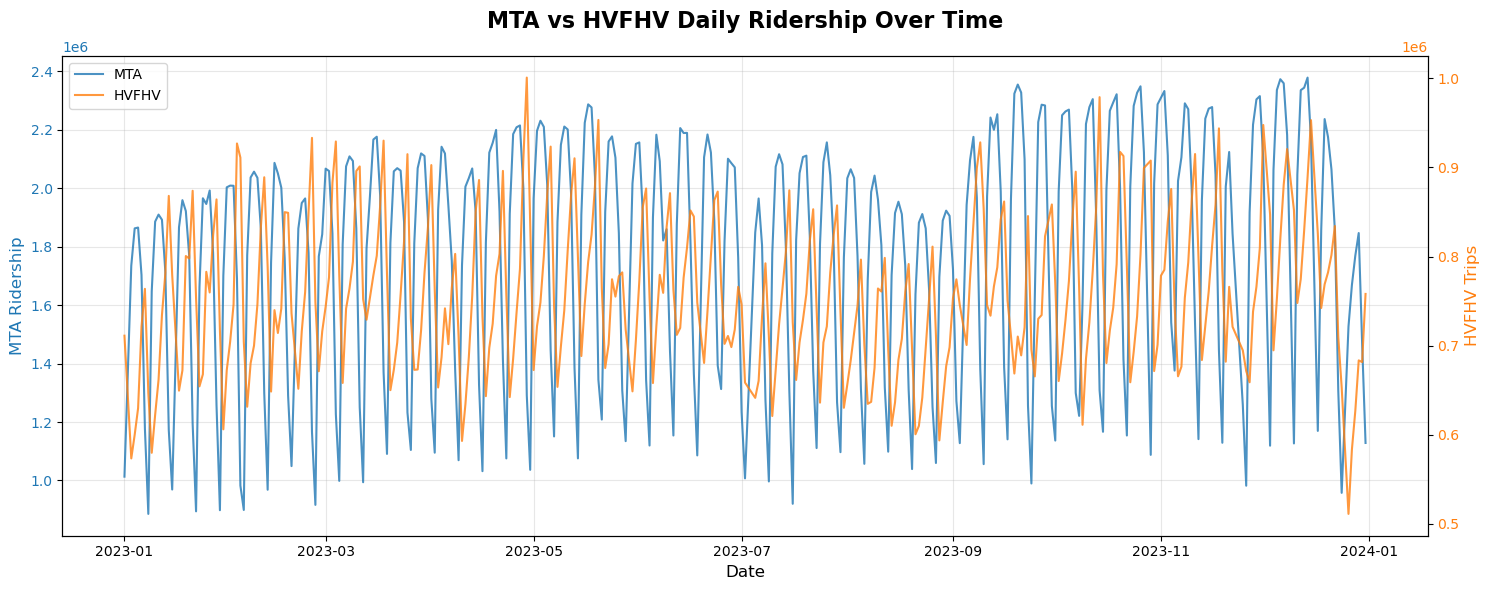

Index(['date', 'trip_count', 'ridership'], dtype='str')
Overall correlation: -0.164


In [15]:
mta_df = pd.read_csv('data/02-processed/MTA_Ridership_cleaned.csv')
print(mta_df.columns)
ridehail_df = pd.read_csv('data/02-processed/total_ridership.csv')
print(ridehail_df.columns)

def plot_mta_vs_ridehail_daily_df(mta_df, ridehail_df):
        """
        Line plot comparing MTA and HVFHV ridership over time
        """
        print(ridehail_df.columns)
        # Aggregate by date
        ridehail_daily_df = ridehail_df.groupby('date')['trip_count'].sum().reset_index()
        mta_daily = mta_df.groupby('date')['ridership'].sum().reset_index()

        # Merge
        daily_df = pd.merge(ridehail_daily_df, mta_daily, on='date')
        daily_df['date'] = pd.to_datetime(daily_df['date'])
        daily_df = daily_df.sort_values('date')

        # Create figure with dual y-axis
        fig, ax1 = plt.subplots(figsize=(15, 6))

        # Plot MTA on primary axis (left)
        color = 'tab:blue'
        ax1.set_xlabel('Date', fontsize=12)
        ax1.set_ylabel('MTA Ridership', color=color, fontsize=12)
        ax1.plot(daily_df['date'], daily_df['ridership'], color=color, 
                linewidth=1.5, alpha=0.8, label='MTA')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, alpha=0.3)

        # Create secondary axis for HVFHV (right)
        ax2 = ax1.twinx()
        color = 'tab:orange'
        ax2.set_ylabel('HVFHV Trips', color=color, fontsize=12)
        ax2.plot(daily_df['date'], daily_df['trip_count'], color=color, 
                linewidth=1.5, alpha=0.8, label='HVFHV')
        ax2.tick_params(axis='y', labelcolor=color)

        # Add title and legend
        plt.title('MTA vs HVFHV Daily Ridership Over Time', fontsize=16, fontweight='bold', pad=20)

        # Combine legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

        plt.tight_layout()
        plt.show()


        print(daily_df.columns)
        # Print correlation
        corr = daily_df['trip_count'].corr(daily_df['ridership'])
        print(f"Overall correlation: {corr:.3f}")

plot_mta_vs_ridehail_daily_df(mta_df, ridehail_df)

Based on this line graph, we can see clear patterns in the ridership of each system, and for most days we observe a clear relationship that shows that HVFHV ridership increases on the weekends and HVFHV ridership decreases on the weekends

Now let's do further experiments to find correlation between Subway useage and HVFHV ridership

Correlation between daily HVFHV trips and MTA ridership: -0.16
Day-of-Week Correlation: -0.3945962841495539
    year  week  weekly_correlation
2   2023     2           -0.616639
4   2023     4           -0.124935
5   2023     5           -0.336873
6   2023     6           -0.528268
7   2023     7           -0.285052
9   2023     9           -0.377583
10  2023    10           -0.199943
11  2023    11           -0.274857
12  2023    12           -0.474287
13  2023    13           -0.472110
14  2023    14           -0.367327
15  2023    15           -0.284151
16  2023    16           -0.350295
17  2023    17           -0.556187
18  2023    18           -0.255576
19  2023    19           -0.400506
20  2023    20           -0.258048
21  2023    21           -0.078715
23  2023    23           -0.362150
24  2023    24           -0.156683
26  2023    26            0.211719
28  2023    28           -0.298024
29  2023    29           -0.345323
30  2023    30           -0.345422
31  2023    31   

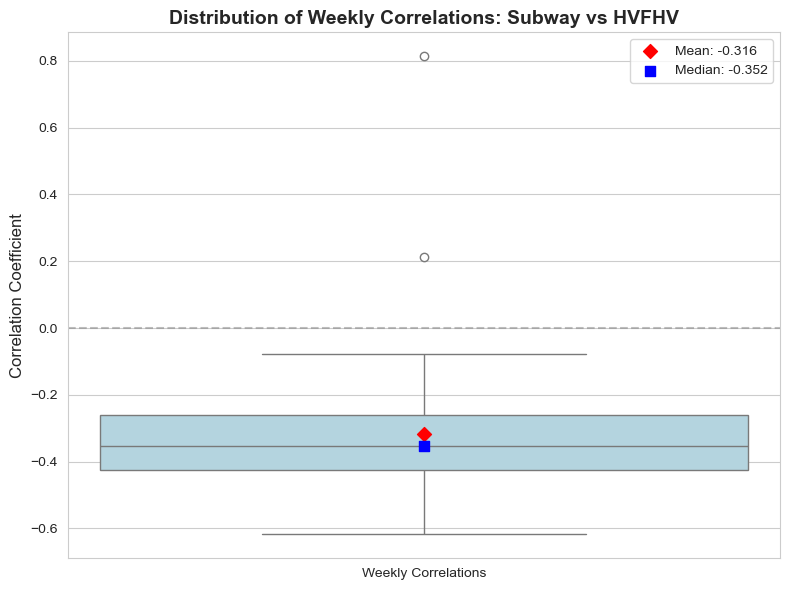

Mean: -0.316
Median: -0.352
Min: -0.617
Max: 0.814


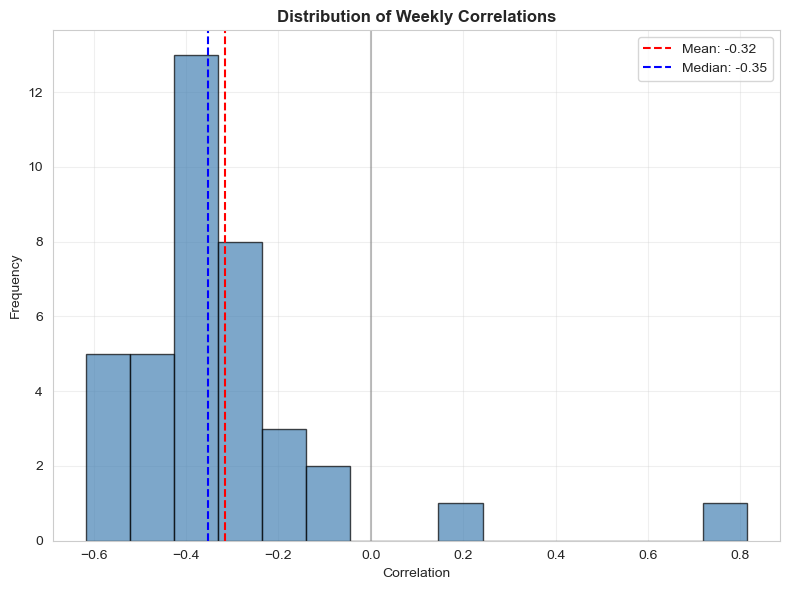

In [21]:
mta_df = pd.read_csv('data/02-processed/MTA_Ridership_cleaned.csv')
mta_df['date'] = pd.to_datetime(mta_df['date'])
#print(mta_df.columns)

ridehail_df = pd.read_csv('data/02-processed/total_ridership.csv')
ridehail_df['date'] = pd.to_datetime(ridehail_df['date'])
ridehail_df['day_of_week'] = ridehail_df['date'].dt.day_name()
#print(ridehail_df.columns)

ridehail_daily_df = ridehail_df.groupby("date")["trip_count"].sum().reset_index()
mta_daily = mta_df.groupby("date")["ridership"].sum().reset_index()
agg_df = pd.merge(ridehail_daily_df, mta_daily, on="date")


correlation = agg_df["trip_count"].corr(agg_df["ridership"])
print(f"Correlation between daily HVFHV trips and MTA ridership: {correlation:.2f}")
#correlation is pretty low

ridehail_dow = ridehail_df.groupby("day_of_week")["trip_count"].mean().reset_index()
# Add day_of_week to mta_df //  Day of the week is already builtin need to do for 
#the other now
# mta_df["day_of_week"] = pd.to_datetime(mta_df["date"]).dt.day_name()

#Now let's sort this by the day of the week
#Now let's see if there's correlation between the days of the week
mta_dow = mta_df.groupby("day_of_week")["ridership"].mean().reset_index()
df_dow = pd.merge(ridehail_dow, mta_dow, on="day_of_week")
correlation = df_dow["trip_count"].corr(df_dow["ridership"])
print("Day-of-Week Correlation:", correlation)


#Now let's see what the variance of the correlation is
daily_df = pd.merge(ridehail_daily_df, mta_daily, on="date")
daily_df["year"] = daily_df["date"].dt.isocalendar().year
daily_df["week"] = daily_df["date"].dt.isocalendar().week

def weekly_corr_func(x):
    if len(x) >= 7:   # require at least 7 days
        return x["trip_count"].corr(x["ridership"])
    else:
        return None


#print(daily_df)
weekly_corr = (
    daily_df
    .groupby(["year", "week"])
    .apply(weekly_corr_func)
    .reset_index(name="weekly_correlation")
)

weekly_corr = weekly_corr.dropna()

print(weekly_corr)

weekly_corr = weekly_corr.dropna()
weekly_corr_clean = weekly_corr["weekly_correlation"].dropna()


# Now let's Create a boxplot of the correlations
# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 6))

# Simple boxplot
sns.boxplot(y=weekly_corr_clean, 
            color='lightblue',
            width=0.3)

# Add mean marker
mean_val = weekly_corr_clean.mean()
plt.scatter(0, mean_val, color='red', s=50, zorder=10, 
           marker='D', label=f'Mean: {mean_val:.3f}')

# Add median marker
median_val = weekly_corr_clean.median()
plt.scatter(0, median_val, color='blue', s=50, zorder=10, 
           marker='s', label=f'Median: {median_val:.3f}')

# Customize
plt.title('Distribution of Weekly Correlations: Subway vs HVFHV', 
          fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xticks([0], ['Weekly Correlations'])
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


#Histogram of weekly correlations
# Print stats
print(f"Mean: {mean_val:.3f}")
print(f"Median: {median_val:.3f}")
print(f"Min: {weekly_corr_clean.min():.3f}")
print(f"Max: {weekly_corr_clean.max():.3f}")

plt.figure(figsize=(8, 6))
plt.hist(weekly_corr_clean, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=weekly_corr_clean.mean(), color='red', linestyle='--', 
            label=f'Mean: {weekly_corr_clean.mean():.2f}')
plt.axvline(x=weekly_corr_clean.median(), color='blue', linestyle='--', 
            label=f'Median: {weekly_corr_clean.median():.2f}')
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
plt.title('Distribution of Weekly Correlations', fontweight='bold')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We're going to do a heat-map of the ridership for the Taxi zones on Wednesday, and Saturday

In [1]:
def plot_heatmap_of_ridership_by_zone(ridehail_df, taxi_zones_gdf):
    """
    Heatmaps of ridership by taxi zone - Wednesday vs Saturday (AVERAGES)
    """

    # Convert date and add day of week
    ridehail_df['date'] = pd.to_datetime(ridehail_df['date'])
    ridehail_df['day_of_week'] = ridehail_df['date'].dt.day_name()

    taxi_zones_gdf['locationid'] = taxi_zones_gdf['locationid'].astype(str)
    ridehail_df['PULocationID'] = ridehail_df['PULocationID'].astype(str)

    # Filter for Wednesday and Saturday
    wednesday_data = ridehail_df[ridehail_df['day_of_week'] == 'Wednesday']
    saturday_data = ridehail_df[ridehail_df['day_of_week'] == 'Saturday']

    # Calculate AVERAGE trips by location for each day (not sum)
    wednesday_avg = wednesday_data.groupby('PULocationID').agg({
        'trip_count': 'mean'  # Changed from 'sum' to 'mean'
    }).reset_index()
    wednesday_avg.columns = ['PULocationID', 'avg_trip_count']

    saturday_avg = saturday_data.groupby('PULocationID').agg({
        'trip_count': 'mean'  # Changed from 'sum' to 'mean'
    }).reset_index()
    saturday_avg.columns = ['PULocationID', 'avg_trip_count']

    # Merge with taxi zones
    zones_wed = taxi_zones_gdf.merge(wednesday_avg, left_on='locationid', right_on='PULocationID', how='left')
    zones_wed['avg_trip_count'] = zones_wed['avg_trip_count'].fillna(0)

    zones_sat = taxi_zones_gdf.merge(saturday_avg, left_on='locationid', right_on='PULocationID', how='left')
    zones_sat['avg_trip_count'] = zones_sat['avg_trip_count'].fillna(0)

    # Create heatmaps - All NYC
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Wednesday heatmap - All NYC
    ax1 = axes[0]
    zones_wed.plot(column='avg_trip_count', 
                ax=ax1,
                legend=True,
                cmap='YlOrRd',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.7,
                legend_kwds={'label': 'Avg Number of Trips',
                            'orientation': 'horizontal',
                            'shrink': 0.8,
                            'pad': 0.05})

    ax1.set_title('HVFHV Avg Ridership - Wednesday (All NYC)', fontsize=14, fontweight='bold')
    ax1.set_axis_off()

    # Saturday heatmap - All NYC
    ax2 = axes[1]
    zones_sat.plot(column='avg_trip_count', 
                ax=ax2,
                legend=True,
                cmap='YlOrRd',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.7,
                legend_kwds={'label': 'Avg Number of Trips',
                            'orientation': 'horizontal',
                            'shrink': 0.8,
                            'pad': 0.05})

    ax2.set_title('HVFHV Avg Ridership - Saturday (All NYC)', fontsize=14, fontweight='bold')
    ax2.set_axis_off()

    plt.suptitle('HVFHV Average Daily Ridership by Taxi Zone: Wednesday vs Saturday', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    # Create heatmaps - Manhattan Only
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Filter for Manhattan zones
    manhattan_wed = zones_wed[zones_wed['borough'] == 'Manhattan']
    manhattan_sat = zones_sat[zones_sat['borough'] == 'Manhattan']

    # Wednesday heatmap - Manhattan
    ax1 = axes[0]
    manhattan_wed.plot(column='avg_trip_count', 
                    ax=ax1,
                    legend=True,
                    cmap='YlOrRd',
                    edgecolor='black',
                    linewidth=0.5,
                    alpha=0.7,
                    legend_kwds={'label': 'Avg Number of Trips',
                                'orientation': 'horizontal',
                                'shrink': 0.8,
                                'pad': 0.05})

    ax1.set_title('HVFHV Avg Ridership - Wednesday (Manhattan)', fontsize=14, fontweight='bold')
    ax1.set_axis_off()

    # Saturday heatmap - Manhattan
    ax2 = axes[1]
    manhattan_sat.plot(column='avg_trip_count', 
                    ax=ax2,
                    legend=True,
                    cmap='YlOrRd',
                    edgecolor='black',
                    linewidth=0.5,
                    alpha=0.7,
                    legend_kwds={'label': 'Avg Number of Trips',
                                'orientation': 'horizontal',
                                'shrink': 0.8,
                                'pad': 0.05})

    ax2.set_title('HVFHV Avg Ridership - Saturday (Manhattan)', fontsize=14, fontweight='bold')
    ax2.set_axis_off()

    plt.suptitle('HVFHV Average Daily Ridership by Taxi Zone: Wednesday vs Saturday (Manhattan)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    # Calculate total averages correctly
    total_wed_avg = wednesday_data.groupby('date')['trip_count'].sum().mean()
    total_sat_avg = saturday_data.groupby('date')['trip_count'].sum().mean()

    # Print Manhattan summary stats
    print("\n" + "=" * 50)
    print("SUMMARY STATISTICS - MANHATTAN ONLY (AVERAGES)")
    print("=" * 50)
    print(f"Average Wednesday Manhattan trips: {manhattan_wed['avg_trip_count'].sum():,.0f}")
    print(f"Average Saturday Manhattan trips: {manhattan_sat['avg_trip_count'].sum():,.0f}")
    print(f"Saturday/Wednesday ratio: {manhattan_sat['avg_trip_count'].sum() / manhattan_wed['avg_trip_count'].sum():.2f}")
    print(f"Manhattan % of NYC Wednesday: {(manhattan_wed['avg_trip_count'].sum() / total_wed_avg * 100):.1f}%")
    print(f"Manhattan % of NYC Saturday: {(manhattan_sat['avg_trip_count'].sum() / total_sat_avg * 100):.1f}%")

    # Top Manhattan zones
    print("\n" + "=" * 50)
    print("TOP 5 MANHATTAN ZONES BY AVERAGE RIDERSHIP")
    print("=" * 50)

    top_manhattan_wed = manhattan_wed.nlargest(5, 'avg_trip_count')[['zone', 'avg_trip_count']]
    top_manhattan_sat = manhattan_sat.nlargest(5, 'avg_trip_count')[['zone', 'avg_trip_count']]

    print("\nWednesday top Manhattan zones:")
    for idx, row in top_manhattan_wed.iterrows():
        print(f"  {row['zone']}: {row['avg_trip_count']:,.0f} avg daily trips")

    print("\nSaturday top Manhattan zones:")
    for idx, row in top_manhattan_sat.iterrows():
        print(f"  {row['zone']}: {row['avg_trip_count']:,.0f} avg daily trips")

    # Find top zones for each day
    print("\n" + "=" * 50)
    print("TOP 5 ZONES BY AVERAGE RIDERSHIP - ALL NYC")
    print("=" * 50)

    if 'zone' in zones_wed.columns:
        top_wed = zones_wed.nlargest(5, 'avg_trip_count')[['zone', 'borough', 'avg_trip_count']]
        top_sat = zones_sat.nlargest(5, 'avg_trip_count')[['zone', 'borough', 'avg_trip_count']]
        
        print("\nWednesday top zones:")
        for idx, row in top_wed.iterrows():
            print(f"  {row['zone']} ({row['borough']}): {row['avg_trip_count']:,.0f} avg daily trips")
        
        print("\nSaturday top zones:")
        for idx, row in top_sat.iterrows():
            print(f"  {row['zone']} ({row['borough']}): {row['avg_trip_count']:,.0f} avg daily trips")

#plot_heatmap_of_ridership_by_zone(ridehail_df, taxi_zones_gdf)

def plot_heatmap_by_day(ridehail_df, taxi_zones_gdf, day_num, summary=False):
    """
    Plot heatmap of HVFHV ridership by taxi zone for a specific day.
    
    Parameters:
    - ridehail_df: HVFHV dataframe
    - taxi_zones_gdf: Taxi zones geodataframe
    - day_num: 1-7 (1=Monday, 2=Tuesday, 3=Wednesday, 4=Thursday, 5=Friday, 6=Saturday, 7=Sunday)
    - summary: If True, print summary stats (default False)
    """
    
    # Map day number to name
    days = {1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 
            5:'Friday', 6:'Saturday', 7:'Sunday'}
    day_name = days[day_num]
    
    # Prepare data
    ridehail_df['date'] = pd.to_datetime(ridehail_df['date'])
    ridehail_df['day_of_week'] = ridehail_df['date'].dt.day_name()
    ridehail_df['PULocationID'] = ridehail_df['PULocationID'].astype(str)
    taxi_zones_gdf['locationid'] = taxi_zones_gdf['locationid'].astype(str)
    
    # Filter for selected day and calculate averages
    day_data = ridehail_df[ridehail_df['day_of_week'] == day_name]
    day_avg = day_data.groupby('PULocationID')['trip_count'].mean().reset_index()
    day_avg.columns = ['PULocationID', 'avg_trip_count']
    
    # Merge with taxi zones and keep only Manhattan
    zones_day = taxi_zones_gdf.merge(day_avg, left_on='locationid', right_on='PULocationID', how='left')
    zones_day['avg_trip_count'] = zones_day['avg_trip_count'].fillna(0)
    manhattan = zones_day[zones_day['borough'] == 'Manhattan']
    
    # Create map
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    manhattan.plot(column='avg_trip_count', 
                   ax=ax,
                   legend=True,
                   cmap='YlOrRd',
                   edgecolor='black',
                   linewidth=0.5,
                   alpha=0.7,
                   legend_kwds={'label': 'Avg Trip Count',
                               'shrink': 0.6})
    
    ax.set_title(f'HVFHV Avg Ridership - {day_name} (Manhattan)', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # Optional summary
    if summary:
        print(f"\n{day_name} - Manhattan Summary:")
        print(f"Total avg trips: {manhattan['avg_trip_count'].sum():,.0f}")
        print("\nTop 5 zones:")
        top = manhattan.nlargest(5, 'avg_trip_count')[['zone', 'avg_trip_count']]
        for idx, row in top.iterrows():
            print(f"  {row['zone']}: {row['avg_trip_count']:,.0f} avg trips")


plot_heatmap_by_day(ridehail_df, taxi_zones_gdf, 3, True)
plot_heatmap_by_day(ridehail_df, taxi_zones_gdf, 6, True)


NameError: name 'ridehail_df' is not defined

As can be seen in the data, on saturday the top destinations are areas known for nightlife, don't drink and drive, get an uber

MAPPING SUBWAY STATIONS TO TAXI ZONES

Taxi zones columns:
[':id', ':version', ':created_at', ':updated_at', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough', 'geometry']

Buffer distance: 0.01 miles (16 meters)
Total stations: 496

Mapping results:
  Stations mapped to zones: 445
  Unique zone-station pairs: 584

Mapping columns:
['Complex ID', 'Stop Name', 'Borough', 'buffer_geom', 'index_right', ':id', ':version', ':created_at', ':updated_at', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough']

Ridership aggregated to 54 zones

Merged zones_wed columns:
[':id', ':version', ':created_at', ':updated_at', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough', 'geometry', 'ridership']


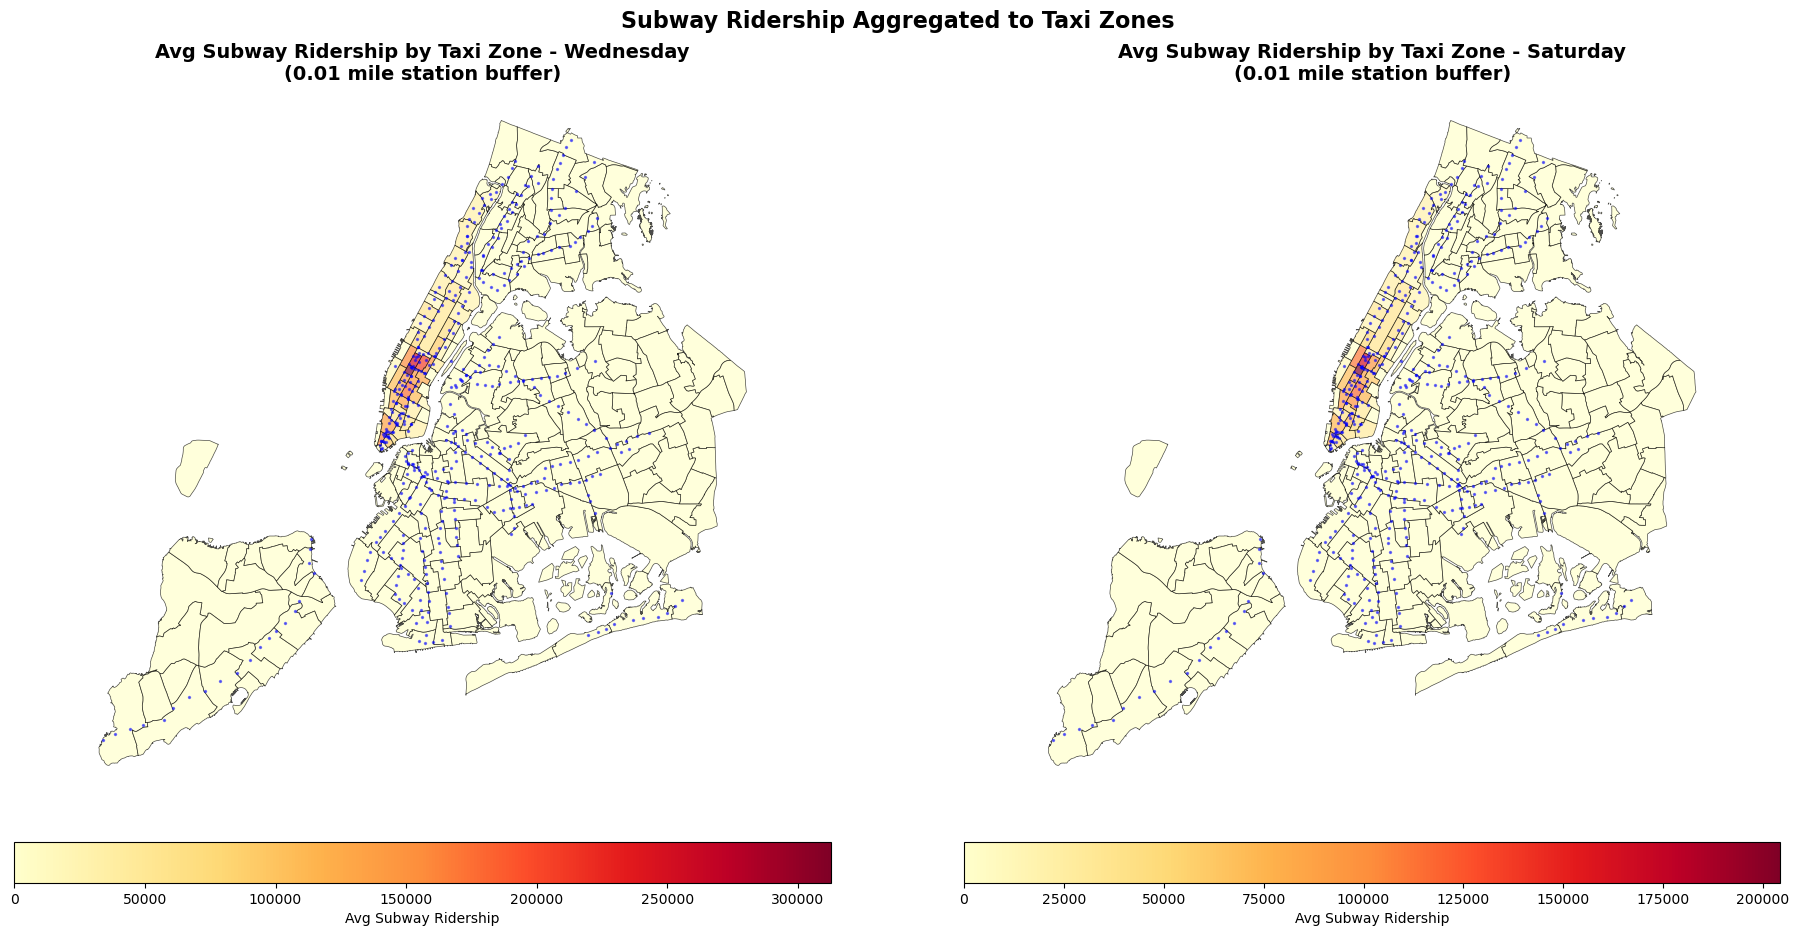


SUMMARY STATISTICS

Wednesday average total subway ridership: 3,966,634
Saturday average total subway ridership: 2,538,267
Saturday/Wednesday ratio: 0.64

TOP 10 ZONES BY SUBWAY RIDERSHIP

Wednesday:
  Garment District (Manhattan): 312,688 avg daily riders
  Times Sq/Theatre District (Manhattan): 248,846 avg daily riders
  Midtown Center (Manhattan): 208,702 avg daily riders
  Union Sq (Manhattan): 174,324 avg daily riders
  World Trade Center (Manhattan): 157,991 avg daily riders

Saturday:
  Garment District (Manhattan): 204,310 avg daily riders
  Times Sq/Theatre District (Manhattan): 163,304 avg daily riders
  Union Sq (Manhattan): 115,933 avg daily riders
  Clinton East (Manhattan): 111,172 avg daily riders
  Greenwich Village North (Manhattan): 98,313 avg daily riders

MANHATTAN-ONLY VIEW


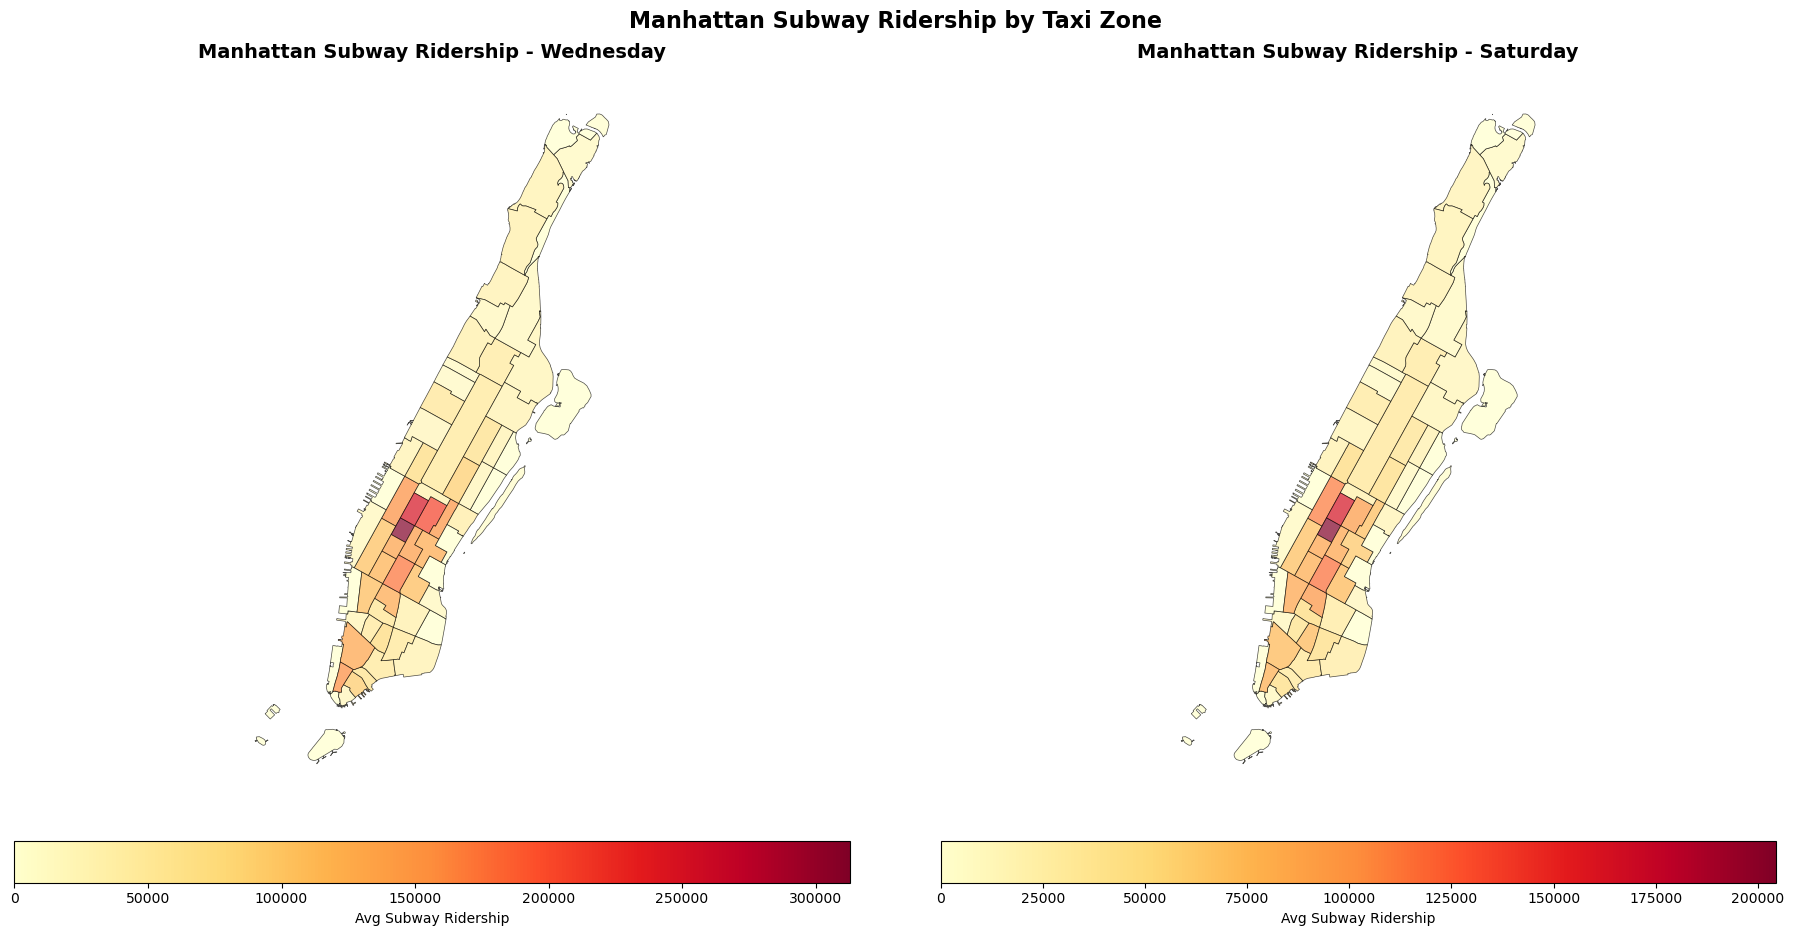

In [ ]:
def plot_subway_to_taxi_zone_mapping(subway_stations_gdf, taxi_zones_gdf, mta_df, 
                                     summary_only=False, selected_date=None):
    """
    Maps subway stations to taxi zones and visualizes ridership patterns.
    
    Parameters:
    -----------
    subway_stations_gdf : GeoDataFrame
        Subway stations with geometry
    taxi_zones_gdf : GeoDataFrame
        Taxi zones with geometry
    mta_df : DataFrame
        MTA ridership data with station_complex_id and ridership
    summary_only : bool, default=False
        If True, only print summary statistics without generating maps
    selected_date : str or datetime, default=None
        Specific date to analyze (e.g., '2023-01-15'). If None, uses averages
    """
    print("=" * 60)
    print("MAPPING SUBWAY STATIONS TO TAXI ZONES")
    print("=" * 60)

    # Check taxi zones columns
    print("\nTaxi zones columns:")
    print(taxi_zones_gdf.columns.tolist())

    # 1. Prepare stations GeoDataFrame
    stations_gdf = subway_stations_gdf.copy()

    # Check and set CRS if needed
    if stations_gdf.crs is None:
        stations_gdf = stations_gdf.set_crs('EPSG:4326')

    # Convert to a projected CRS for accurate buffering (meters)
    stations_gdf = stations_gdf.to_crs('EPSG:3857')
    taxi_zones_gdf = taxi_zones_gdf.to_crs('EPSG:3857')

    # 2. Set buffer distance
    buffer_distance_miles = 0.5  # Increased to 0.5 miles for better coverage
    buffer_distance_meters = buffer_distance_miles * 1609.34

    # Create buffers - store in a separate column
    stations_gdf['buffer_geom'] = stations_gdf.geometry.buffer(buffer_distance_meters)

    print(f"\nBuffer distance: {buffer_distance_miles} miles ({buffer_distance_meters:.0f} meters)")
    print(f"Total stations: {len(stations_gdf)}")

    # 3. Spatial join using the buffer geometry
    stations_buffer_gdf = stations_gdf[['Complex ID', 'Stop Name', 'Borough']].copy()
    stations_buffer_gdf = stations_buffer_gdf.set_geometry(stations_gdf['buffer_geom'])
    stations_buffer_gdf.crs = stations_gdf.crs

    station_zone_mapping = gpd.sjoin(
        stations_buffer_gdf,
        taxi_zones_gdf,
        how='left',
        predicate='intersects'
    )

    # Drop duplicate station-zone combinations
    station_zone_mapping = station_zone_mapping.drop_duplicates(subset=['Complex ID', 'locationid'])

    print(f"\nMapping results:")
    print(f"  Stations mapped to zones: {station_zone_mapping['Complex ID'].nunique()}")
    print(f"  Unique zone-station pairs: {len(station_zone_mapping)}")
    
    # Show stations that didn't map to any zone
    mapped_stations = set(station_zone_mapping['Complex ID'].unique())
    all_stations = set(stations_gdf['Complex ID'].unique())
    unmapped_stations = all_stations - mapped_stations
    if unmapped_stations:
        print(f"  Stations NOT mapped to any zone: {len(unmapped_stations)}")
        print(f"  Example unmapped stations: {list(unmapped_stations)[:5]}")

    # 4. Prepare MTA ridership data
    mta_df['date'] = pd.to_datetime(mta_df['date'])
    mta_df['station_complex_id'] = mta_df['station_complex_id'].astype(str)
    station_zone_mapping['Complex ID'] = station_zone_mapping['Complex ID'].astype(str)

    # Merge ridership with zone mapping
    station_zone_ridership = station_zone_mapping.merge(
        mta_df,
        left_on='Complex ID',
        right_on='station_complex_id',
        how='left'
    )

    # 5. Filter by selected date if provided
    if selected_date is not None:
        selected_date = pd.to_datetime(selected_date)
        print(f"\n" + "=" * 60)
        print(f"ANALYZING SPECIFIC DATE: {selected_date.strftime('%Y-%m-%d')} ({selected_date.day_name()})")
        print("=" * 60)
        
        # Filter for the selected date
        date_filtered_ridership = station_zone_ridership[
            station_zone_ridership['date'] == selected_date
        ]
        
        # Aggregate ridership by taxi zone for the selected date
        zone_daily_ridership = date_filtered_ridership.groupby(['date', 'locationid']).agg({
            'ridership': 'sum'
        }).reset_index()
        
        date_desc = selected_date.strftime('%Y-%m-%d')
    else:
        print(f"\n" + "=" * 60)
        print("ANALYZING AVERAGE PATTERNS (ALL DATES)")
        print("=" * 60)
        
        # Aggregate ridership by taxi zone and date
        zone_daily_ridership = station_zone_ridership.groupby(['date', 'locationid']).agg({
            'ridership': 'sum'
        }).reset_index()
        
        date_desc = "Average"

    print(f"\nRidership aggregated to {zone_daily_ridership['locationid'].nunique()} zones")

    # 6. Add day of week
    zone_daily_ridership['date'] = pd.to_datetime(zone_daily_ridership['date'])
    zone_daily_ridership['day_of_week'] = zone_daily_ridership['date'].dt.day_name()

    # 7. Filter for Wednesday and Saturday (or specific date)
    if selected_date is not None:
        # For specific date, just get the day name
        selected_day = selected_date.day_name()
        
        # Create dataframes for the two comparisons
        wednesday_data = zone_daily_ridership[zone_daily_ridership['day_of_week'] == 'Wednesday']
        selected_data = zone_daily_ridership[zone_daily_ridership['date'] == selected_date]
        
        # Calculate average for Wednesdays (all Wednesdays in dataset)
        wednesday_avg = wednesday_data.groupby('locationid').agg({
            'ridership': 'mean'
        }).reset_index()
        wednesday_avg.columns = ['locationid', 'wednesday_avg']
        
        # Get the selected date data
        selected_avg = selected_data.groupby('locationid').agg({
            'ridership': 'mean'
        }).reset_index()
        selected_avg.columns = ['locationid', 'selected_ridership']
        
        # Merge for comparison
        comparison_data = wednesday_avg.merge(selected_avg, on='locationid', how='outer').fillna(0)
        
        # Create dataframes for mapping
        zones_wed = taxi_zones_gdf.merge(wednesday_avg, on='locationid', how='left')
        zones_wed['wednesday_avg'] = zones_wed['wednesday_avg'].fillna(0)
        
        zones_selected = taxi_zones_gdf.merge(selected_avg, on='locationid', how='left')
        zones_selected['selected_ridership'] = zones_selected['selected_ridership'].fillna(0)
    else:
        # Original behavior: compare Wednesday vs Saturday averages
        wednesday_zone_rides = zone_daily_ridership[zone_daily_ridership['day_of_week'] == 'Wednesday']
        saturday_zone_rides = zone_daily_ridership[zone_daily_ridership['day_of_week'] == 'Saturday']

        # Calculate average ridership by zone for each day
        wednesday_avg = wednesday_zone_rides.groupby('locationid').agg({
            'ridership': 'mean'
        }).reset_index()

        saturday_avg = saturday_zone_rides.groupby('locationid').agg({
            'ridership': 'mean'
        }).reset_index()

        # Merge with taxi zones for mapping
        zones_wed = taxi_zones_gdf.merge(wednesday_avg, on='locationid', how='left')
        zones_wed['ridership'] = zones_wed['ridership'].fillna(0)

        zones_sat = taxi_zones_gdf.merge(saturday_avg, on='locationid', how='left')
        zones_sat['ridership'] = zones_sat['ridership'].fillna(0)

    # Skip visualization if summary_only is True
    if not summary_only:
        if selected_date is not None:
            # Plot comparison between selected date and average Wednesday
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))

            # Selected date heatmap
            ax1 = axes[0]
            zones_selected.plot(column='selected_ridership',
                              ax=ax1,
                              legend=True,
                              cmap='YlOrRd',
                              edgecolor='black',
                              linewidth=0.5,
                              alpha=0.7,
                              legend_kwds={'label': f'Subway Ridership - {selected_date.strftime("%Y-%m-%d")}',
                                          'orientation': 'horizontal',
                                          'shrink': 0.8,
                                          'pad': 0.05})

            # Plot subway stations
            stations_gdf.plot(ax=ax1, color='blue', markersize=2, alpha=0.5, label='Subway Stations')

            ax1.set_title(f'Subway Ridership by Taxi Zone - {selected_date.strftime("%Y-%m-%d")} ({selected_day})',
                        fontsize=14, fontweight='bold')
            ax1.set_axis_off()

            # Wednesday average heatmap
            ax2 = axes[1]
            zones_wed.plot(column='wednesday_avg',
                          ax=ax2,
                          legend=True,
                          cmap='YlOrRd',
                          edgecolor='black',
                          linewidth=0.5,
                          alpha=0.7,
                          legend_kwds={'label': 'Avg Subway Ridership - Wednesdays',
                                      'orientation': 'horizontal',
                                      'shrink': 0.8,
                                      'pad': 0.05})

            # Plot subway stations
            stations_gdf.plot(ax=ax2, color='blue', markersize=2, alpha=0.5, label='Subway Stations')

            ax2.set_title(f'Average Subway Ridership by Taxi Zone - Wednesdays\n({buffer_distance_miles} mile station buffer)',
                        fontsize=14, fontweight='bold')
            ax2.set_axis_off()

            plt.suptitle(f'Subway Ridership: {selected_date.strftime("%Y-%m-%d")} vs Average Wednesday',
                        fontsize=16, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()
        else:
            # Original Wednesday vs Saturday comparison
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))

            # Wednesday heatmap
            ax1 = axes[0]
            zones_wed.plot(column='ridership',
                          ax=ax1,
                          legend=True,
                          cmap='YlOrRd',
                          edgecolor='black',
                          linewidth=0.5,
                          alpha=0.7,
                          legend_kwds={'label': 'Avg Subway Ridership',
                                      'orientation': 'horizontal',
                                      'shrink': 0.8,
                                      'pad': 0.05})

            # Plot subway stations
            stations_gdf.plot(ax=ax1, color='blue', markersize=2, alpha=0.5, label='Subway Stations')

            ax1.set_title(f'Avg Subway Ridership by Taxi Zone - Wednesday\n({buffer_distance_miles} mile station buffer)',
                        fontsize=14, fontweight='bold')
            ax1.set_axis_off()

            # Saturday heatmap
            ax2 = axes[0]  # Fixed: should be axes[1]
            zones_sat.plot(column='ridership',
                          ax=ax2,
                          legend=True,
                          cmap='YlOrRd',
                          edgecolor='black',
                          linewidth=0.5,
                          alpha=0.7,
                          legend_kwds={'label': 'Avg Subway Ridership',
                                      'orientation': 'horizontal',
                                      'shrink': 0.8,
                                      'pad': 0.05})

            # Plot subway stations
            stations_gdf.plot(ax=ax2, color='blue', markersize=2, alpha=0.5, label='Subway Stations')

            ax2.set_title(f'Avg Subway Ridership by Taxi Zone - Saturday\n({buffer_distance_miles} mile station buffer)',
                        fontsize=14, fontweight='bold')
            ax2.set_axis_off()

            plt.suptitle('Subway Ridership Aggregated to Taxi Zones', fontsize=16, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()

    # 10. Summary statistics
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS")
    print("=" * 60)

    if selected_date is not None:
        print(f"\nSelected date: {selected_date.strftime('%Y-%m-%d')} ({selected_day})")
        print(f"Total subway ridership on selected date: {selected_avg['selected_ridership'].sum():,.0f}")
        print(f"Average Wednesday total subway ridership: {wednesday_avg['wednesday_avg'].sum():,.0f}")
        print(f"Selected date / Wednesday ratio: {selected_avg['selected_ridership'].sum() / wednesday_avg['wednesday_avg'].sum():.2f}")
        
        # Top zones for selected date
        print("\n" + "=" * 60)
        print(f"TOP 10 ZONES - {selected_date.strftime('%Y-%m-%d')}")
        print("=" * 60)
        
        if 'zone' in zones_selected.columns and 'borough' in zones_selected.columns:
            top_zones = zones_selected.nlargest(10, 'selected_ridership')[['zone', 'borough', 'selected_ridership']]
            for idx, row in top_zones.iterrows():
                print(f"  {row['zone']} ({row['borough']}): {row['selected_ridership']:,.0f} riders")
        else:
            top_zones = zones_selected.nlargest(10, 'selected_ridership')[['locationid', 'selected_ridership']]
            for idx, row in top_zones.iterrows():
                print(f"  Zone {row['locationid']}: {row['selected_ridership']:,.0f} riders")
    else:
        print(f"\nWednesday average total subway ridership: {wednesday_avg['ridership'].sum():,.0f}")
        print(f"Saturday average total subway ridership: {saturday_avg['ridership'].sum():,.0f}")
        print(f"Saturday/Wednesday ratio: {saturday_avg['ridership'].sum() / wednesday_avg['ridership'].sum():.2f}")

        # Top zones comparison
        print("\n" + "=" * 60)
        print("TOP 10 ZONES BY SUBWAY RIDERSHIP")
        print("=" * 60)

        if 'zone' in zones_wed.columns and 'borough' in zones_wed.columns:
            print("\nWednesday:")
            top_wed = zones_wed.nlargest(10, 'ridership')[['zone', 'borough', 'ridership']]
            for idx, row in top_wed.iterrows():
                print(f"  {row['zone']} ({row['borough']}): {row['ridership']:,.0f} avg daily riders")

            print("\nSaturday:")
            top_sat = zones_sat.nlargest(10, 'ridership')[['zone', 'borough', 'ridership']]
            for idx, row in top_sat.iterrows():
                print(f"  {row['zone']} ({row['borough']}): {row['ridership']:,.0f} avg daily riders")
        else:
            print("\nWednesday top zones:")
            top_wed = zones_wed.nlargest(10, 'ridership')[['locationid', 'ridership']]
            for idx, row in top_wed.iterrows():
                print(f"  Zone {row['locationid']}: {row['ridership']:,.0f} avg daily riders")
            
            print("\nSaturday top zones:")
            top_sat = zones_sat.nlargest(10, 'ridership')[['locationid', 'ridership']]
            for idx, row in top_sat.iterrows():
                print(f"  Zone {row['locationid']}: {row['ridership']:,.0f} avg daily riders")

    # Manhattan-only view (if not summary_only)
    if not summary_only and 'borough' in (zones_wed if selected_date is None else zones_selected).columns:
        print("\n" + "=" * 60)
        print("MANHATTAN-ONLY VIEW")
        print("=" * 60)

        if selected_date is not None:
            manhattan_selected = zones_selected[zones_selected['borough'] == 'Manhattan']
            manhattan_wed = zones_wed[zones_wed['borough'] == 'Manhattan']
            
            if len(manhattan_selected) > 0:
                fig, axes = plt.subplots(1, 2, figsize=(20, 10))

                # Manhattan selected date
                ax1 = axes[0]
                manhattan_selected.plot(column='selected_ridership',
                                      ax=ax1,
                                      legend=True,
                                      cmap='YlOrRd',
                                      edgecolor='black',
                                      linewidth=0.5,
                                      alpha=0.7,
                                      legend_kwds={'label': f'Ridership - {selected_date.strftime("%Y-%m-%d")}',
                                                  'orientation': 'horizontal',
                                                  'shrink': 0.8,
                                                  'pad': 0.05})

                # Plot only Manhattan stations
                manhattan_stations = stations_gdf[stations_gdf['Borough'] == 'Manhattan']
                if len(manhattan_stations) > 0:
                    manhattan_stations.plot(ax=ax1, color='blue', markersize=3, alpha=0.5, label='Subway Stations')

                ax1.set_title(f'Manhattan Subway Ridership - {selected_date.strftime("%Y-%m-%d")}',
                            fontsize=14, fontweight='bold')
                ax1.set_axis_off()

                # Manhattan Wednesday average
                ax2 = axes[1]
                manhattan_wed.plot(column='wednesday_avg',
                                 ax=ax2,
                                 legend=True,
                                 cmap='YlOrRd',
                                 edgecolor='black',
                                 linewidth=0.5,
                                 alpha=0.7,
                                 legend_kwds={'label': 'Avg Ridership - Wednesdays',
                                             'orientation': 'horizontal',
                                             'shrink': 0.8,
                                             'pad': 0.05})

                if len(manhattan_stations) > 0:
                    manhattan_stations.plot(ax=ax2, color='blue', markersize=3, alpha=0.5, label='Subway Stations')

                ax2.set_title('Manhattan Subway Ridership - Average Wednesday', fontsize=14, fontweight='bold')
                ax2.set_axis_off()

                plt.suptitle(f'Manhattan Subway Ridership by Taxi Zone', fontsize=16, fontweight='bold', y=0.98)
                plt.tight_layout()
                plt.show()
        else:
            manhattan_wed = zones_wed[zones_wed['borough'] == 'Manhattan']
            manhattan_sat = zones_sat[zones_sat['borough'] == 'Manhattan']

            if len(manhattan_wed) > 0:
                fig, axes = plt.subplots(1, 2, figsize=(20, 10))

                # Manhattan Wednesday
                ax1 = axes[0]
                manhattan_wed.plot(column='ridership',
                                 ax=ax1,
                                 legend=True,
                                 cmap='YlOrRd',
                                 edgecolor='black',
                                 linewidth=0.5,
                                 alpha=0.7,
                                 legend_kwds={'label': 'Avg Subway Ridership',
                                             'orientation': 'horizontal',
                                             'shrink': 0.8,
                                             'pad': 0.05})

                # Plot only Manhattan stations
                manhattan_stations = stations_gdf[stations_gdf['Borough'] == 'Manhattan']
                if len(manhattan_stations) > 0:
                    manhattan_stations.plot(ax=ax1, color='blue', markersize=3, alpha=0.5, label='Subway Stations')

                ax1.set_title('Manhattan Subway Ridership - Wednesday', fontsize=14, fontweight='bold')
                ax1.set_axis_off()

                # Manhattan Saturday
                ax2 = axes[1]
                manhattan_sat.plot(column='ridership',
                                 ax=ax2,
                                 legend=True,
                                 cmap='YlOrRd',
                                 edgecolor='black',
                                 linewidth=0.5,
                                 alpha=0.7,
                                 legend_kwds={'label': 'Avg Subway Ridership',
                                             'orientation': 'horizontal',
                                             'shrink': 0.8,
                                             'pad': 0.05})

                if len(manhattan_stations) > 0:
                    manhattan_stations.plot(ax=ax2, color='blue', markersize=3, alpha=0.5, label='Subway Stations')

                ax2.set_title('Manhattan Subway Ridership - Saturday', fontsize=14, fontweight='bold')
                ax2.set_axis_off()

                plt.suptitle('Manhattan Subway Ridership by Taxi Zone', fontsize=16, fontweight='bold', y=0.98)
                plt.tight_layout()
                plt.show()

    # Return data for further analysis if needed
    if selected_date is not None:
        return {
            'selected_date': selected_date,
            'selected_data': selected_avg,
            'wednesday_avg': wednesday_avg,
            'comparison': comparison_data,
            'zones_selected': zones_selected,
            'zones_wed': zones_wed
        }
    else:
        return {
            'wednesday_avg': wednesday_avg,
            'saturday_avg': saturday_avg,
            'zones_wed': zones_wed,
            'zones_sat': zones_sat
        }

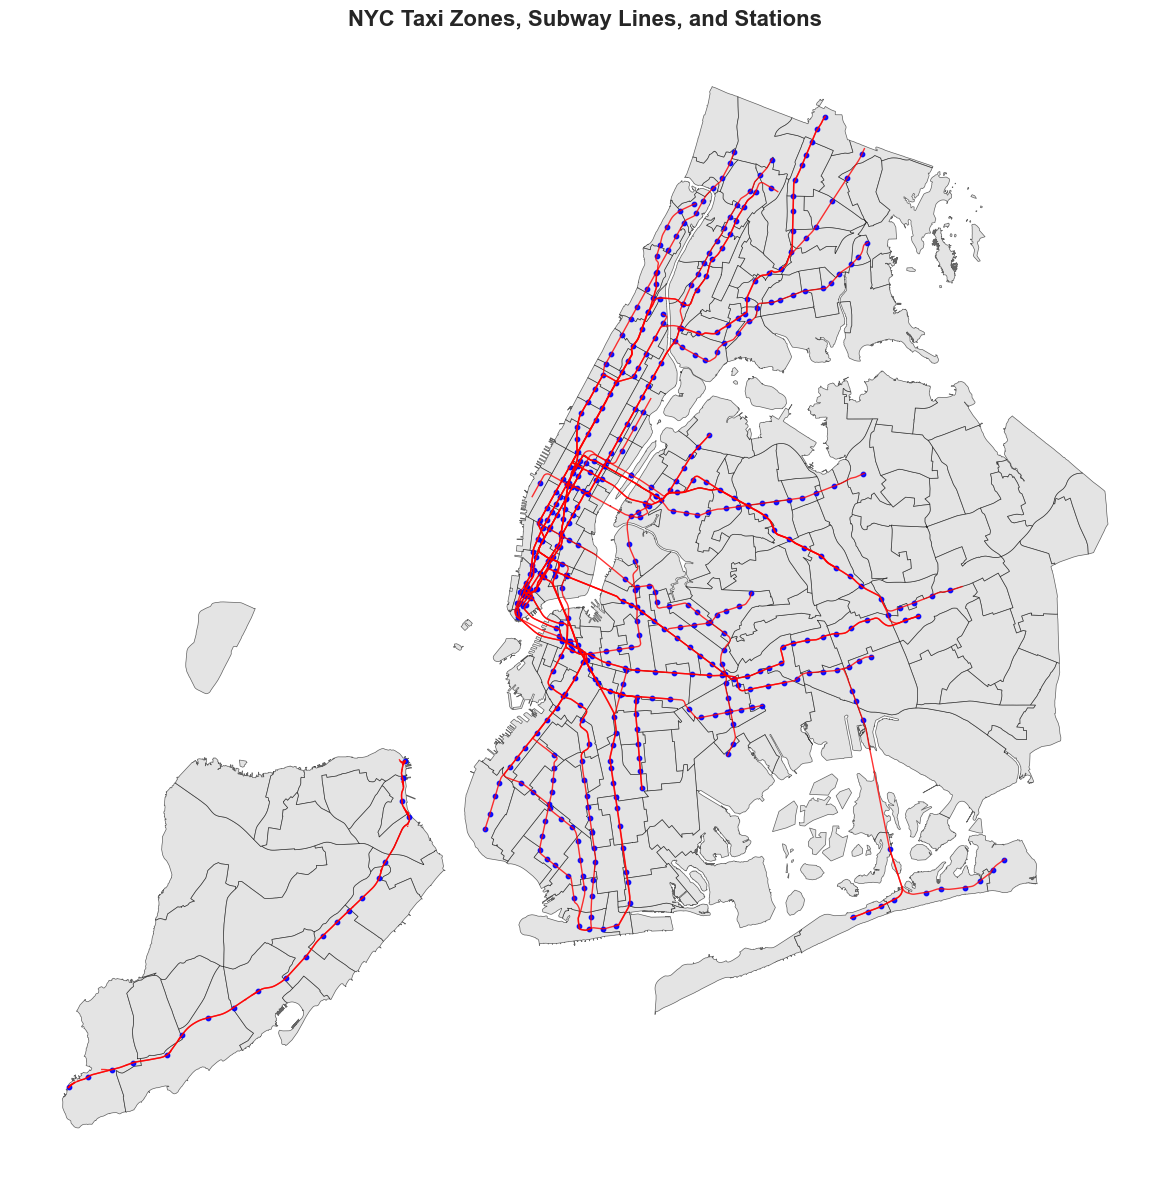

Manhattan stations: 153
Manhattan unique complexes: 121


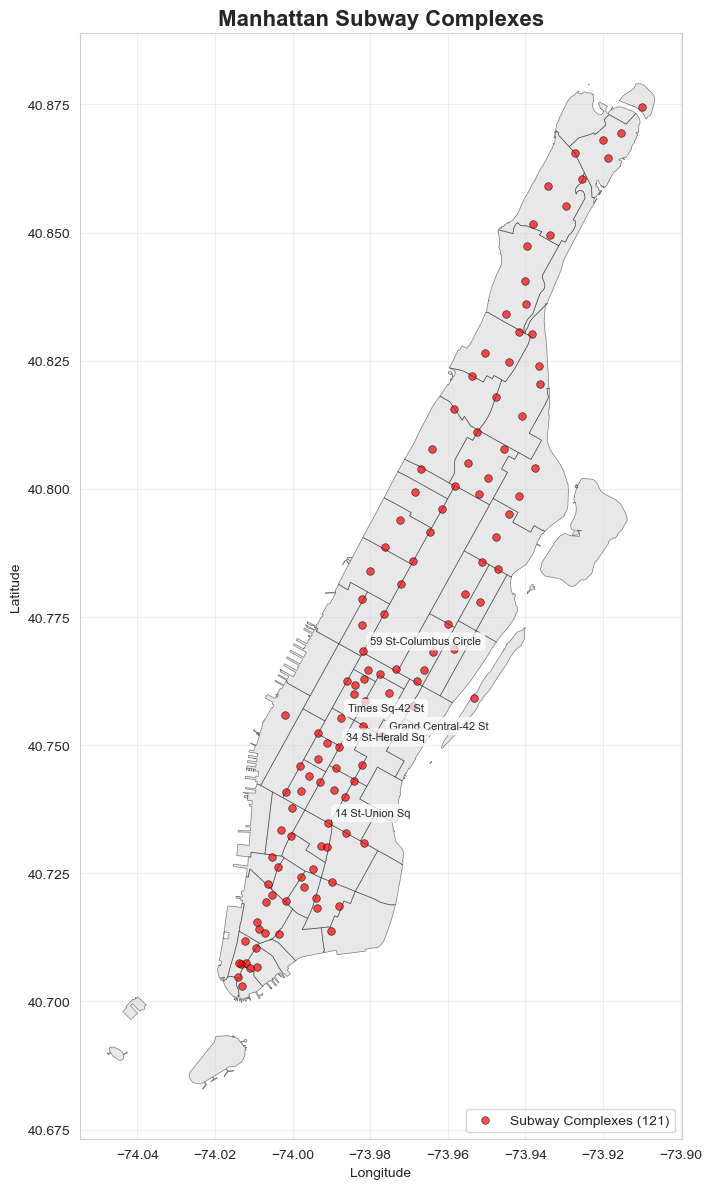


Sample of Manhattan complexes:
 Complex ID          Stop Name
        611     Times Sq-42 St
        471 34 St-Hudson Yards
        234      East Broadway
        624        Chambers St
        613              59 St
          8         5 Av/59 St
        393             116 St
         14              23 St
         13              28 St
        304             145 St


In [104]:
maps.plot_transit_map(subway_stations_gdf, taxi_zones_gdf, subway_lines_gdf)
def plot_manhattan_subway_complexes(subway_stations_gdf, taxi_zones_gdf):
    """
    Simple map of Manhattan showing unique subway complexes
    """
    
    # 1. Filter for Manhattan stations
    manhattan_stations = subway_stations_gdf[subway_stations_gdf['Borough'] == 'M'].copy()
    
    # 2. Get unique complexes by dropping duplicates based on Complex ID
    # This keeps the first occurrence of each complex
    manhattan_complexes = manhattan_stations.drop_duplicates(subset=['Complex ID'])
    
    print(f"Manhattan stations: {len(manhattan_stations)}")
    print(f"Manhattan unique complexes: {len(manhattan_complexes)}")
    
    # 3. Filter Manhattan zones
    manhattan_zones = taxi_zones_gdf[taxi_zones_gdf['borough'] == 'Manhattan'].copy()
    
    # 4. Create the map
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    # Plot Manhattan taxi zones (light gray background)
    manhattan_zones.plot(ax=ax, 
                        color='lightgray',
                        edgecolor='black',
                        linewidth=0.5,
                        alpha=0.5)
    
    # Plot subway complexes as red points
    manhattan_complexes.plot(ax=ax, 
                            color='red', 
                            markersize=30, 
                            marker='o',
                            alpha=0.7,
                            edgecolor='black',
                            linewidth=0.5,
                            label=f'Subway Complexes ({len(manhattan_complexes)})')
    
    # Add labels for major complexes (optional)
    major_complexes = ['Times Sq-42 St', 'Grand Central-42 St', '34 St-Herald Sq', 
                      '14 St-Union Sq', '59 St-Columbus Circle', '42 St-Bryant Pk']
    
    for idx, row in manhattan_complexes.iterrows():
        if row['Stop Name'] in major_complexes:
            ax.annotate(row['Stop Name'], 
                       xy=(row.geometry.x, row.geometry.y),
                       xytext=(5, 5), 
                       textcoords='offset points',
                       fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax.set_title('Manhattan Subway Complexes', fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    # Show sample of complexes
    print("\nSample of Manhattan complexes:")
    print(manhattan_complexes[['Complex ID', 'Stop Name']].head(10).to_string(index=False))
    
    return manhattan_complexes

# Run it
manhattan_complexes = plot_manhattan_subway_complexes(subway_stations_gdf, taxi_zones_gdf)

Now that we have these heatmaps of both the taxi zones and the subway, let's create a heatmap that shows the ratio of the two

In [84]:
def plot_hvfhv_to_subway_ratio_heatmap(hvfhv_df, zones_wed, zones_sat, taxi_zones_gdf):
    """
    Heatmap showing ratio of normalized HVFHV to normalized Subway ridership by taxi zone
    """

    print("=" * 60)
    print("RATIO HEATMAP: NORMALIZED HVFHV vs NORMALIZED SUBWAY RIDERSHIP")
    print("=" * 60)

    # First, get subway ridership by zone (from your existing code)
    # Assuming zones_wed and zones_sat already exist from previous code

    # Now get HVFHV ridership by zone for Wednesday and Saturday
    # Convert date and add day of week
    hvfhv_df['date'] = pd.to_datetime(hvfhv_df['date'])
    hvfhv_df['day_of_week'] = hvfhv_df['date'].dt.day_name()
    hvfhv_df['PULocationID'] = hvfhv_df['PULocationID'].astype(str)

    # Filter for Wednesday and Saturday
    hvfhv_wed_data = hvfhv_df[hvfhv_df['day_of_week'] == 'Wednesday']
    hvfhv_sat_data = hvfhv_df[hvfhv_df['day_of_week'] == 'Saturday']

    # Calculate average HVFHV trips by zone
    hvfhv_wed_avg = hvfhv_wed_data.groupby('PULocationID').agg({
        'trip_count': 'mean'
    }).reset_index()
    hvfhv_wed_avg.columns = ['locationid', 'hvfhv_avg']

    hvfhv_sat_avg = hvfhv_sat_data.groupby('PULocationID').agg({
        'trip_count': 'mean'
    }).reset_index()
    hvfhv_sat_avg.columns = ['locationid', 'hvfhv_avg']

    # Merge HVFHV data with taxi zones
    zones_hvfhv_wed = taxi_zones_gdf.merge(hvfhv_wed_avg, on='locationid', how='left')
    zones_hvfhv_wed['hvfhv_avg'] = zones_hvfhv_wed['hvfhv_avg'].fillna(0)

    zones_hvfhv_sat = taxi_zones_gdf.merge(hvfhv_sat_avg, on='locationid', how='left')
    zones_hvfhv_sat['hvfhv_avg'] = zones_hvfhv_sat['hvfhv_avg'].fillna(0)

    # Make sure locationid is string in both
    zones_wed['locationid'] = zones_wed['locationid'].astype(str)
    zones_sat['locationid'] = zones_sat['locationid'].astype(str)

    # Combine HVFHV and subway data
    zones_combined_wed = zones_wed.merge(
        zones_hvfhv_wed[['locationid', 'hvfhv_avg']], 
        on='locationid', 
        how='left'
    )

    zones_combined_sat = zones_sat.merge(
        zones_hvfhv_sat[['locationid', 'hvfhv_avg']], 
        on='locationid', 
        how='left'
    )
    print(zones_combined_wed.columns)

    # NORMALIZE the values (z-score normalization)
    # For Wednesday
    mean_subway_wed = zones_combined_wed['avg_trip_count'].mean()
    std_subway_wed = zones_combined_wed['avg_trip_count'].std()
    mean_hvfhv_wed = zones_combined_wed['hvfhv_avg'].mean()
    std_hvfhv_wed = zones_combined_wed['hvfhv_avg'].std()

    zones_combined_wed['subway_norm'] = (zones_combined_wed['avg_trip_count'] - mean_subway_wed) / std_subway_wed
    zones_combined_wed['hvfhv_norm'] = (zones_combined_wed['hvfhv_avg'] - mean_hvfhv_wed) / std_hvfhv_wed

    # For Saturday
    mean_subway_sat = zones_combined_sat['avg_trip_count'].mean()
    std_subway_sat = zones_combined_sat['avg_trip_count'].std()
    mean_hvfhv_sat = zones_combined_sat['hvfhv_avg'].mean()
    std_hvfhv_sat = zones_combined_sat['hvfhv_avg'].std()

    zones_combined_sat['subway_norm'] = (zones_combined_sat['avg_trip_count'] - mean_subway_sat) / std_subway_sat
    zones_combined_sat['hvfhv_norm'] = (zones_combined_sat['hvfhv_avg'] - mean_hvfhv_sat) / std_hvfhv_sat

    # Calculate ratio of normalized values
    # Add small offset to avoid division by zero
    zones_combined_wed['norm_ratio'] = zones_combined_wed['hvfhv_norm'] / (zones_combined_wed['subway_norm'] + 0.001)
    zones_combined_sat['norm_ratio'] = zones_combined_sat['hvfhv_norm'] / (zones_combined_sat['subway_norm'] + 0.001)

    # Cap extreme values for better visualization (e.g., between -3 and 3)
    zones_combined_wed['norm_ratio_capped'] = zones_combined_wed['norm_ratio'].clip(lower=-3, upper=3)
    zones_combined_sat['norm_ratio_capped'] = zones_combined_sat['norm_ratio'].clip(lower=-3, upper=3)

    # Create ratio heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Wednesday ratio heatmap
    ax1 = axes[0]
    zones_combined_wed.plot(column='norm_ratio_capped',
                            ax=ax1,
                            legend=True,
                            cmap='RdBu',  # Red=HVFHV dominates, Blue=Subway dominates
                            edgecolor='black',
                            linewidth=0.5,
                            alpha=0.7,
                            legend_kwds={'label': 'Normalized HVFHV/Subway Ratio',
                                        'orientation': 'horizontal',
                                        'shrink': 0.8,
                                        'pad': 0.05})

    # Plot subway stations for context
    stations_gdf.plot(ax=ax1, color='black', markersize=2, alpha=0.5, label='Subway Stations')

    ax1.set_title('Normalized HVFHV/Subway Ratio - Wednesday\n(Red = More HVFHV than expected, Blue = More Subway than expected)', 
                fontsize=14, fontweight='bold')
    ax1.set_axis_off()

    # Saturday ratio heatmap
    ax2 = axes[1]
    zones_combined_sat.plot(column='norm_ratio_capped',
                            ax=ax2,
                            legend=True,
                            cmap='RdBu',
                            edgecolor='black',
                            linewidth=0.5,
                            alpha=0.7,
                            legend_kwds={'label': 'Normalized HVFHV/Subway Ratio',
                                        'orientation': 'horizontal',
                                        'shrink': 0.8,
                                        'pad': 0.05})

    # Plot subway stations
    stations_gdf.plot(ax=ax2, color='black', markersize=2, alpha=0.5, label='Subway Stations')

    ax2.set_title('Normalized HVFHV/Subway Ratio - Saturday\n(Red = More HVFHV than expected, Blue = More Subway than expected)', 
                fontsize=14, fontweight='bold')
    ax2.set_axis_off()

    plt.suptitle('Normalized HVFHV to Subway Ratio by Taxi Zone', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    # Manhattan-only ratio view
    if 'borough' in zones_combined_wed.columns:
        print("\n" + "=" * 60)
        print("MANHATTAN-ONLY RATIO VIEW (NORMALIZED)")
        print("=" * 60)

        manhattan_ratio_wed = zones_combined_wed[zones_combined_wed['borough'] == 'Manhattan']
        manhattan_ratio_sat = zones_combined_sat[zones_combined_sat['borough'] == 'Manhattan']

        if len(manhattan_ratio_wed) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))

            # Manhattan Wednesday
            ax1 = axes[0]
            manhattan_ratio_wed.plot(column='norm_ratio_capped',
                                    ax=ax1,
                                    legend=True,
                                    cmap='RdBu',
                                    edgecolor='black',
                                    linewidth=0.5,
                                    alpha=0.7,
                                    legend_kwds={'label': 'Normalized HVFHV/Subway Ratio',
                                                'orientation': 'horizontal',
                                                'shrink': 0.8,
                                                'pad': 0.05})

            # Plot Manhattan stations
            manhattan_stations = stations_gdf[stations_gdf['Borough'] == 'Manhattan']
            if len(manhattan_stations) > 0:
                manhattan_stations.plot(ax=ax1, color='black', markersize=3, alpha=0.5, label='Subway Stations')

            ax1.set_title('Manhattan Normalized Ratio - Wednesday', fontsize=14, fontweight='bold')
            ax1.set_axis_off()

            # Manhattan Saturday
            ax2 = axes[1]
            manhattan_ratio_sat.plot(column='norm_ratio_capped',
                                    ax=ax2,
                                    legend=True,
                                    cmap='RdBu',
                                    edgecolor='black',
                                    linewidth=0.5,
                                    alpha=0.7,
                                    legend_kwds={'label': 'Normalized HVFHV/Subway Ratio',
                                                'orientation': 'horizontal',
                                                'shrink': 0.8,
                                                'pad': 0.05})

            if len(manhattan_stations) > 0:
                manhattan_stations.plot(ax=ax2, color='black', markersize=3, alpha=0.5, label='Subway Stations')

            ax2.set_title('Manhattan Normalized Ratio - Saturday', fontsize=14, fontweight='bold')
            ax2.set_axis_off()

            plt.suptitle('Manhattan Normalized HVFHV to Subway Ratio', fontsize=16, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()

    # Print summary statistics
    print("\n" + "=" * 60)
    print("NORMALIZED RATIO STATISTICS")
    print("=" * 60)

    print("\nInterpretation:")
    print("  Ratio > 0: Zone has more HVFHV relative to its average than subway relative to its average")
    print("  Ratio < 0: Zone has more subway relative to its average than HVFHV relative to its average")
    print("  Ratio = 0: Zone has balanced normalized values")

    print(f"\nWednesday average normalized ratio: {zones_combined_wed['norm_ratio'].mean():.3f}")
    print(f"Saturday average normalized ratio: {zones_combined_sat['norm_ratio'].mean():.3f}")

    # Find zones with extreme ratios
    print("\n" + "=" * 60)
    print("ZONES WITH EXTREME NORMALIZED RATIOS")
    print("=" * 60)

    if 'zone' in zones_combined_wed.columns:
        print("\nWednesday - HVFHV dominated (Red zones):")
        top_hvfhv_wed = zones_combined_wed.nlargest(5, 'norm_ratio')[['zone', 'borough', 'norm_ratio', 'subway_norm', 'hvfhv_norm']]
        for idx, row in top_hvfhv_wed.iterrows():
            print(f"  {row['zone']} ({row['borough']}): Ratio={row['norm_ratio']:.2f} (Subway norm: {row['subway_norm']:.2f}, HVFHV norm: {row['hvfhv_norm']:.2f})")
        
        print("\nWednesday - Subway dominated (Blue zones):")
        top_subway_wed = zones_combined_wed.nsmallest(5, 'norm_ratio')[['zone', 'borough', 'norm_ratio', 'subway_norm', 'hvfhv_norm']]
        for idx, row in top_subway_wed.iterrows():
            print(f"  {row['zone']} ({row['borough']}): Ratio={row['norm_ratio']:.2f} (Subway norm: {row['subway_norm']:.2f}, HVFHV norm: {row['hvfhv_norm']:.2f})")

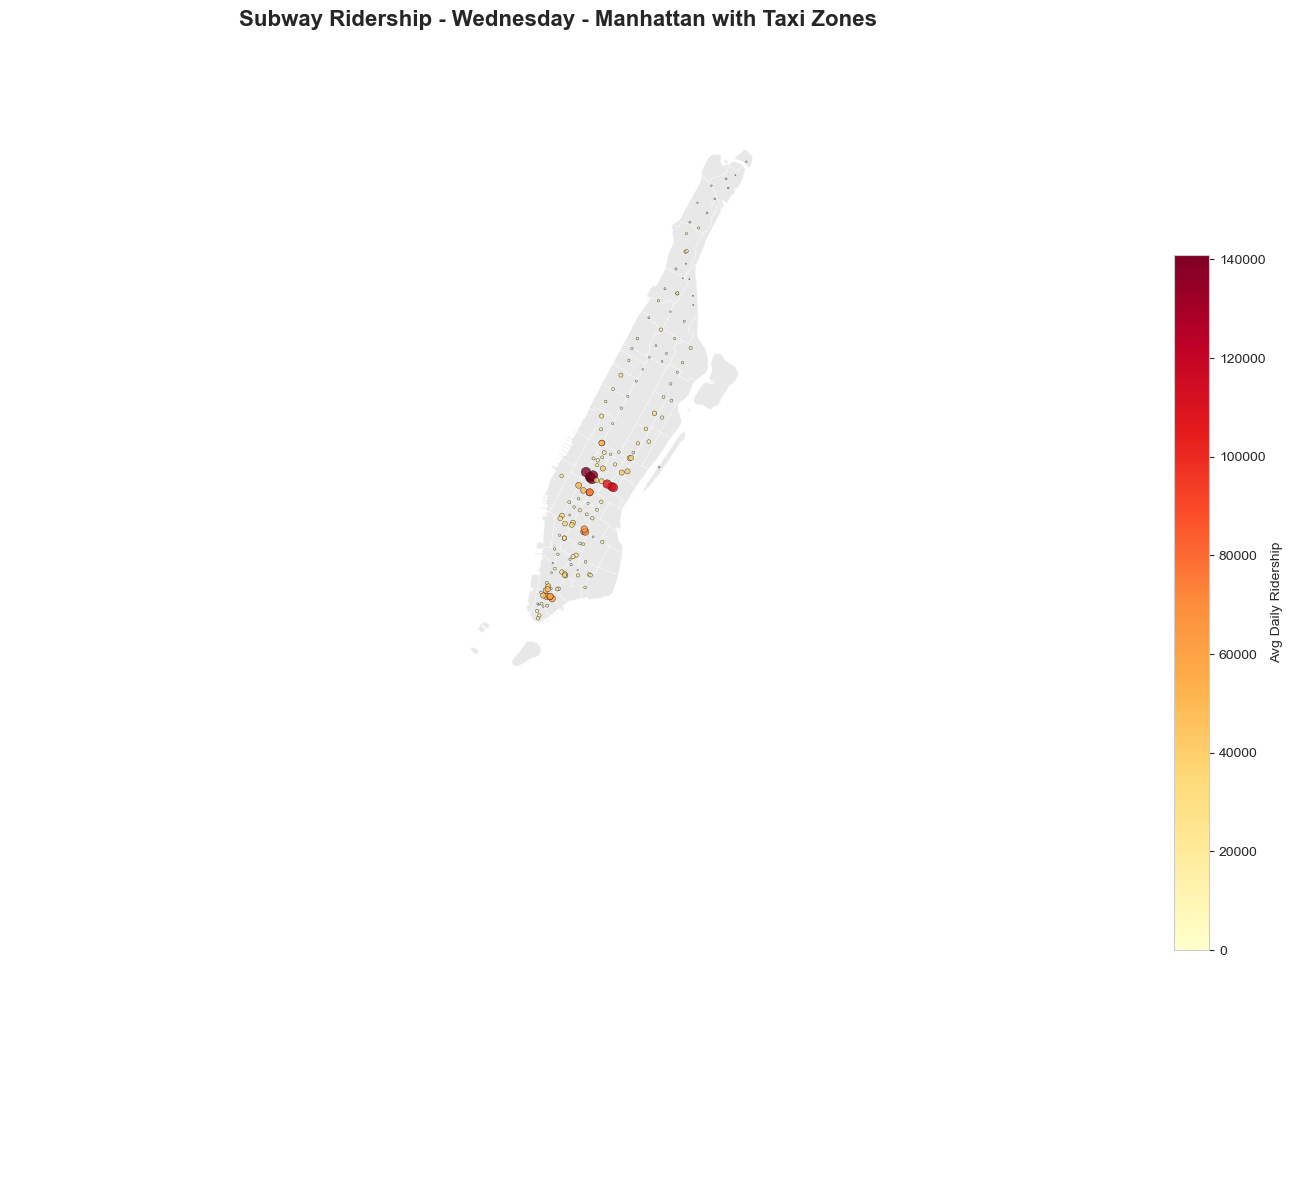

Total stations: 153
Total ridership: 3,966,906


,Station ID,Complex ID,Line,Stop Name,Borough,GTFS Latitude,GTFS Longitude,geometry,station_complex_id,avg_ridership
0,317,611,Broadway - 7Av,Times Sq-42 St,M,40.755290,-73.987495,POINT (-73.9875 40.75529),611,140774.576923
1,515,515,Staten Island,Annadale,SI,40.540460,-74.178217,POINT (-74.17822 40.54046),NaN,0.000000
2,139,627,Franklin Shuttle,Franklin Av,Bk,40.680596,-73.955827,POINT (-73.95583 40.6806),NaN,0.000000
3,349,349,Eastern Pky,Junius St,Bk,40.663515,-73.902447,POINT (-73.90245 40.66352),NaN,0.000000
4,108,108,Myrtle Av,Middle Village-Metropolitan Av,Q,40.711396,-73.889601,POINT (-73.8896 40.7114),NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
491,222,222,63rd St,Roosevelt Island,M,40.759145,-73.953260,POINT (-73.95326 40.75914),222,5178.288462
492,83,83,Jamaica,Woodhaven Blvd,Q,40.693879,-73.851576,POINT (-73.85158 40.69388),NaN,0.000000
493,514,514,Staten Island,Eltingville,SI,40.544601,-74.164570,POINT (-74.16457 40.5446),NaN,0.000000
494,232,232,6th Av - Culver,2 Av,M,40.723402,-73.989938,POINT (-73.98994 40.7234),232,12007.173077


In [107]:
def plot_subway_ridership_with_zones(subway_stations_gdf, taxi_zones_gdf, mta_df, day_name=None, borough='Manhattan'):
    """
    Plot subway ridership heatmap overlaid on taxi zone map.
    
    Parameters:
    - day_name: None for overall average, or 'Monday','Tuesday',etc.
    - borough: 'Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island', or None for all
    """
    
    # 1. Prepare subway ridership data
    mta_df['date'] = pd.to_datetime(mta_df['date'])
    
    if day_name:
        mta_df['day_of_week'] = mta_df['date'].dt.day_name()
        day_data = mta_df[mta_df['day_of_week'] == day_name]
        station_avg = day_data.groupby('station_complex_id')['ridership'].mean().reset_index()
        title_day = f" - {day_name}"
    else:
        station_avg = mta_df.groupby('station_complex_id')['ridership'].mean().reset_index()
        title_day = " (Average All Days)"
    
    station_avg.columns = ['station_complex_id', 'avg_ridership']
    
    # Merge with station geometries
    subway_stations_gdf['Complex ID'] = subway_stations_gdf['Complex ID'].astype(str)
    station_avg['station_complex_id'] = station_avg['station_complex_id'].astype(str)
    
    stations_with_ridership = subway_stations_gdf.merge(
        station_avg,
        left_on='Complex ID',
        right_on='station_complex_id',
        how='left'
    )
    stations_with_ridership['avg_ridership'] = stations_with_ridership['avg_ridership'].fillna(0)
    
    # 2. Filter zones by borough if specified
    if borough:
        zones_plot = taxi_zones_gdf[taxi_zones_gdf['borough'] == borough].copy()
        title_borough = borough
    else:
        zones_plot = taxi_zones_gdf.copy()
        title_borough = "NYC"
    
    # 3. Create the map
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    
    # Plot taxi zones as light gray background
    zones_plot.plot(ax=ax,
                   color='lightgray',
                   edgecolor='white',
                   linewidth=0.5,
                   alpha=0.5)
    
    # Plot subway stations with size/color representing ridership
    scatter = stations_with_ridership.plot(ax=ax,
                                          column='avg_ridership',
                                          cmap='YlOrRd',
                                          markersize=stations_with_ridership['avg_ridership'] / 3000,
                                          alpha=0.8,
                                          edgecolor='black',
                                          linewidth=0.3,
                                          legend=True,
                                          legend_kwds={'label': 'Avg Daily Ridership',
                                                      'shrink': 0.6})
    
    ax.set_title(f'Subway Ridership{title_day} - {title_borough} with Taxi Zones', 
                fontsize=16, fontweight='bold')
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # Print stats
    print(f"Total stations: {len(stations_with_ridership[stations_with_ridership['avg_ridership'] > 0])}")
    print(f"Total ridership: {stations_with_ridership['avg_ridership'].sum():,.0f}")
    
    return stations_with_ridership

# Examples:
# plot_subway_ridership_with_zones(subway_stations_gdf, taxi_zones_gdf, mta_df)  # Overall, all boroughs
plot_subway_ridership_with_zones(subway_stations_gdf, taxi_zones_gdf, mta_df, 'Wednesday', 'Manhattan')
# plot_subway_ridership_with_zones(subway_stations_gdf, taxi_zones_gdf, mta_df, 'Saturday', 'Brooklyn')

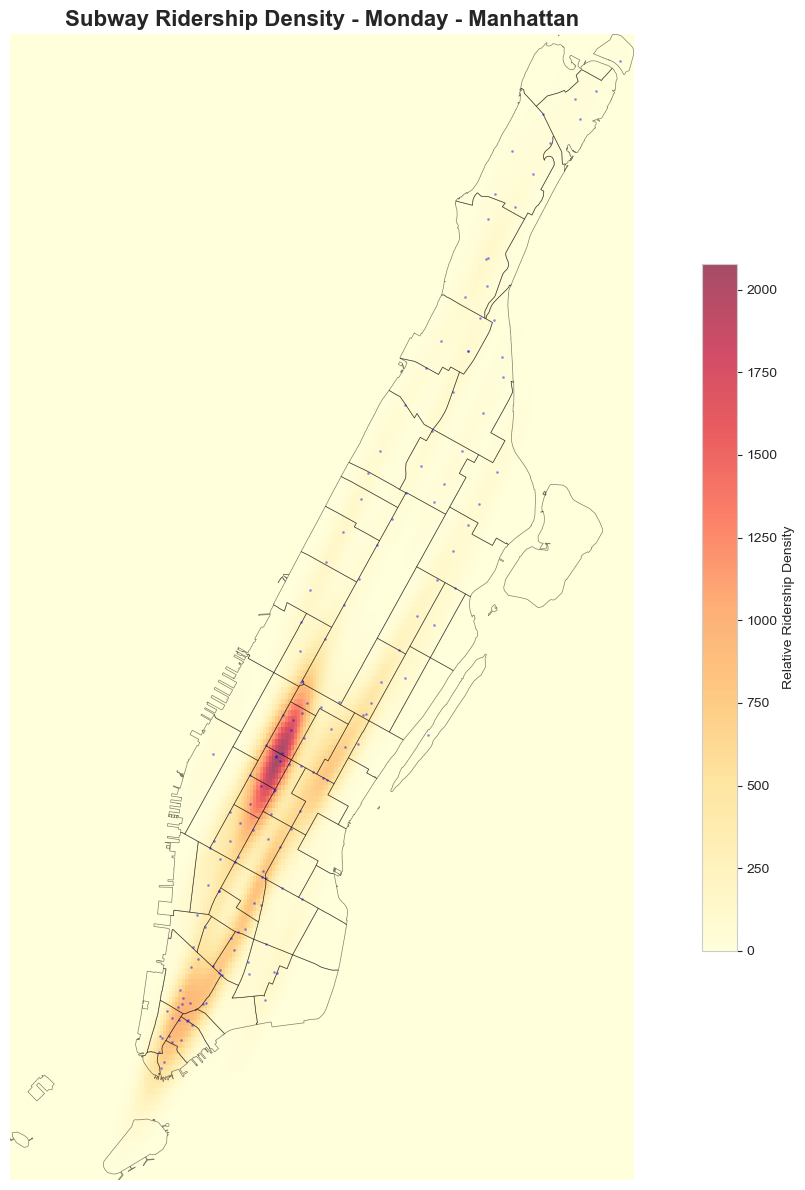

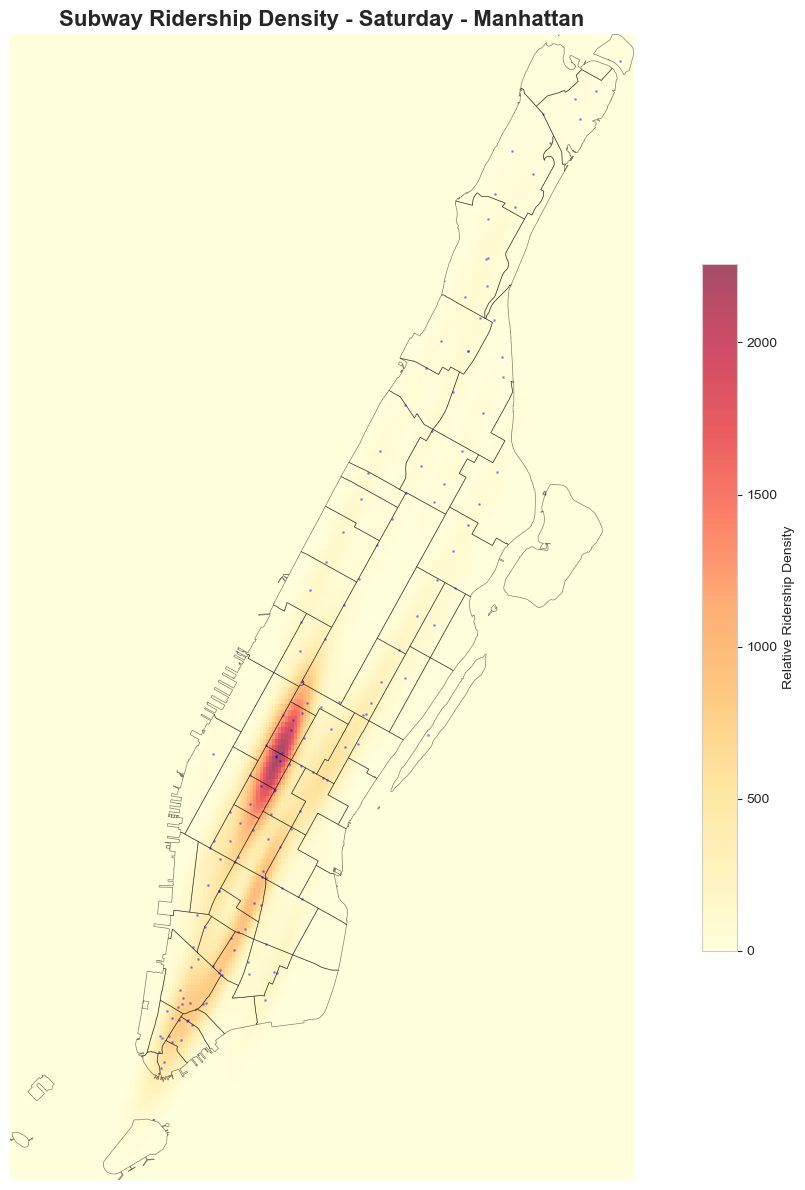

In [ ]:
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

def plot_subway_ridership_kde(subway_stations_gdf, taxi_zones_gdf, mta_df, day_name=None, borough='Manhattan'):
    """
    Create a gradient heatmap of subway ridership using kernel density estimation.
    """
    
    # 1. Prepare subway ridership data (same as before)
    mta_df['date'] = pd.to_datetime(mta_df['date'])
    
    if day_name:
        mta_df['day_of_week'] = mta_df['date'].dt.day_name()
        day_data = mta_df[mta_df['day_of_week'] == day_name]
        station_avg = day_data.groupby('station_complex_id')['ridership'].mean().reset_index()
        title_day = f" - {day_name}"
    else:
        station_avg = mta_df.groupby('station_complex_id')['ridership'].mean().reset_index()
        title_day = " (Average All Days)"
    
    station_avg.columns = ['station_complex_id', 'avg_ridership']
    
    # Merge with station geometries
    subway_stations_gdf['Complex ID'] = subway_stations_gdf['Complex ID'].astype(str)
    station_avg['station_complex_id'] = station_avg['station_complex_id'].astype(str)
    
    stations_with_ridership = subway_stations_gdf.merge(
        station_avg,
        left_on='Complex ID',
        right_on='station_complex_id',
        how='left'
    )
    stations_with_ridership['avg_ridership'] = stations_with_ridership['avg_ridership'].fillna(0)
    
    # Filter out zero ridership stations
    stations_with_data = stations_with_ridership[stations_with_ridership['avg_ridership'] > 0].copy()
    
    # 2. Filter zones by borough
    if borough:
        zones_plot = taxi_zones_gdf[taxi_zones_gdf['borough'] == borough].copy()
        title_borough = borough
    else:
        zones_plot = taxi_zones_gdf.copy()
        title_borough = "NYC"
    
    # 3. Create grid for KDE
    bounds = zones_plot.total_bounds  # (minx, miny, maxx, maxy)
    
    # Create a grid of points
    grid_size = 200
    x_grid = np.linspace(bounds[0], bounds[2], grid_size)
    y_grid = np.linspace(bounds[1], bounds[3], grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 4. Perform weighted KDE
    # Extract coordinates and weights
    coords = np.array([(geom.x, geom.y) for geom in stations_with_data.geometry])
    weights = stations_with_data['avg_ridership'].values
    
    # Create weighted KDE
    # We need to repeat points based on weights for KDE
    # This is a simplification - for large datasets, consider using a proper weighted KDE
    repeated_coords = []
    for coord, weight in zip(coords, weights):
        # Scale weight to reasonable number of repeats
        n_repeats = max(1, int(weight / 1000))  # Adjust divisor based on your data scale
        repeated_coords.extend([coord] * n_repeats)
    
    repeated_coords = np.array(repeated_coords)
    
    if len(repeated_coords) > 0:
        # Calculate KDE
        kde = gaussian_kde(repeated_coords.T)
        positions = np.vstack([X.ravel(), Y.ravel()])
        Z = kde(positions).reshape(X.shape)
        
        # 5. Create the map
        fig, ax = plt.subplots(1, 1, figsize=(14, 12))
        
        # Plot taxi zones as outlines
        zones_plot.plot(ax=ax,
                       facecolor='none',
                       edgecolor='black',
                       linewidth=0.5,
                       alpha=0.5)
        
        # Plot the KDE heatmap
        im = ax.imshow(Z, extent=[bounds[0], bounds[2], bounds[1], bounds[3]],
                       origin='lower', cmap='YlOrRd', alpha=0.7,
                       aspect='auto')
        
        plt.colorbar(im, ax=ax, label='Relative Ridership Density', shrink=0.6)
        
        # Plot station locations for reference (optional)
        stations_with_data.plot(ax=ax, color='blue', markersize=5, 
                               alpha=0.3, marker='.', label='Stations')
        
        ax.set_title(f'Subway Ridership Density{title_day} - {title_borough}', 
                    fontsize=16, fontweight='bold')
        ax.set_axis_off()
        
        plt.tight_layout()
        plt.show()
    else:
        print("No stations with ridership data found")

plot_subway_ridership_kde(subway_stations_gdf, taxi_zones_gdf, mta_df,"Monday")
plot_subway_ridership_kde(subway_stations_gdf, taxi_zones_gdf, mta_df, "Saturday")

In [ ]:
def eliminate_ridership_outliers(ridehail_df, mta_df):
    mta_df = pd.read_csv("data/01-interim/MTA_subway/MTA_Subway_Daily_Manhattan_Totals.csv")
    # Convert dates
    ridehail_df['date'] = pd.to_datetime(ridehail_df['date'])
    mta_df['date'] = pd.to_datetime(mta_df['date'])
    
    # Add day of week columns
    ridehail_df['day_of_week'] = ridehail_df['date'].dt.day_name()
    mta_df['day_of_week'] = mta_df['date'].dt.day_name()
    
    # Add weekend column (using dayofweek numbers: 5=Saturday, 6=Sunday)
    ridehail_df['weekend'] = ridehail_df['date'].dt.dayofweek.isin([5, 6])
    mta_df['weekend'] = mta_df['date'].dt.dayofweek.isin([5, 6])
    
    # Split data into weekday and weekend
    weekday_data = mta_df[~mta_df['weekend']]
    weekend_data = mta_df[mta_df['weekend']]
    
    # Calculate statistics for weekdays
    weekday_mean = weekday_data['ridership'].mean()
    weekday_std = weekday_data['ridership'].std()
    weekday_upper_threshold = weekday_mean + (2 * weekday_std)
    weekday_lower_threshold = weekday_mean - (2 * weekday_std)
    weekday_upper_outliers = weekday_data[weekday_data['ridership'] > weekday_upper_threshold]
    weekday_lower_outliers = weekday_data[weekday_data['ridership'] < weekday_lower_threshold]
    
    # Calculate statistics for weekends
    weekend_mean = weekend_data['ridership'].mean()
    weekend_std = weekend_data['ridership'].std()
    weekend_upper_threshold = weekend_mean + (2 * weekend_std)
    weekend_lower_threshold = weekend_mean - (2 * weekend_std)
    weekend_upper_outliers = weekend_data[weekend_data['ridership'] > weekend_upper_threshold]
    weekend_lower_outliers = weekend_data[weekend_data['ridership'] < weekend_lower_threshold]
    
    # Print weekday outliers
    print("=" * 60)
    print("WEEKDAY ANALYSIS")
    print("=" * 60)
    print(f"Mean ridership (Weekdays): {weekday_mean:.2f}")
    print(f"Standard deviation: {weekday_std:.2f}")
    print(f"Upper 3-sigma threshold (+3σ): {weekday_upper_threshold:.2f}")
    print(f"Lower 3-sigma threshold (-3σ): {weekday_lower_threshold:.2f}")
    
    print(f"\n📈 WEEKDAY - HIGH OUTLIERS (above +3σ): {len(weekday_upper_outliers)} days found")
    print("-" * 50)
    if len(weekday_upper_outliers) > 0:
        for idx, row in weekday_upper_outliers.iterrows():
            print(f"Date: {row['date'].strftime('%Y-%m-%d')}, "
                  f"Ridership: {row['ridership']:.0f}, "
                  f"Day: {row['day_of_week']} "
                  f"(+{(row['ridership'] - weekday_mean)/weekday_std:.2f}σ)")
    else:
        print("No weekday high outliers found above +3σ")
    
    print(f"\n📉 WEEKDAY - LOW OUTLIERS (below -3σ): {len(weekday_lower_outliers)} days found")
    print("-" * 50)
    if len(weekday_lower_outliers) > 0:
        for idx, row in weekday_lower_outliers.iterrows():
            print(f"Date: {row['date'].strftime('%Y-%m-%d')}, "
                  f"Ridership: {row['ridership']:.0f}, "
                  f"Day: {row['day_of_week']} "
                  f"({(row['ridership'] - weekday_mean)/weekday_std:.2f}σ)")
    else:
        print("No weekday low outliers found below -3σ")
    
    # Print weekend outliers
    print("\n" + "=" * 60)
    print("WEEKEND ANALYSIS")
    print("=" * 60)
    print(f"Mean ridership (Weekends): {weekend_mean:.2f}")
    print(f"Standard deviation: {weekend_std:.2f}")
    print(f"Upper 3-sigma threshold (+3σ): {weekend_upper_threshold:.2f}")
    print(f"Lower 3-sigma threshold (-3σ): {weekend_lower_threshold:.2f}")
    
    print(f"\n📈 WEEKEND - HIGH OUTLIERS (above +3σ): {len(weekend_upper_outliers)} days found")
    print("-" * 50)
    if len(weekend_upper_outliers) > 0:
        for idx, row in weekend_upper_outliers.iterrows():
            print(f"Date: {row['date'].strftime('%Y-%m-%d')}, "
                  f"Ridership: {row['ridership']:.0f}, "
                  f"Day: {row['day_of_week']} "
                  f"(+{(row['ridership'] - weekend_mean)/weekend_std:.2f}σ)")
    else:
        print("No weekend high outliers found above +3σ")
    
    print(f"\n📉 WEEKEND - LOW OUTLIERS (below -3σ): {len(weekend_lower_outliers)} days found")
    print("-" * 50)
    if len(weekend_lower_outliers) > 0:
        for idx, row in weekend_lower_outliers.iterrows():
            print(f"Date: {row['date'].strftime('%Y-%m-%d')}, "
                  f"Ridership: {row['ridership']:.0f}, "
                  f"Day: {row['day_of_week']} "
                  f"({(row['ridership'] - weekend_mean)/weekend_std:.2f}σ)")
    else:
        print("No weekend low outliers found below -3σ")
    
    # Create histograms
    import matplotlib.pyplot as plt
    
    # Set up the figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Histogram for all days
    axes[0].hist(mta_df['ridership'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(mta_df['ridership'].mean(), color='red', linestyle='-', linewidth=2, label='Overall Mean')
    axes[0].set_title(f'MTA Ridership - All Days')
    axes[0].set_xlabel('Ridership')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    
    # Histogram for weekdays with thresholds
    axes[1].hist(weekday_data['ridership'], bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[1].axvline(weekday_mean, color='red', linestyle='-', linewidth=2, label='Weekday Mean')
    axes[1].axvline(weekday_upper_threshold, color='orange', linestyle='--', linewidth=2, 
                    label=f'+3σ ({weekday_upper_threshold:.0f})')
    axes[1].axvline(weekday_lower_threshold, color='purple', linestyle='--', linewidth=2, 
                    label=f'-3σ ({weekday_lower_threshold:.0f})')
    axes[1].set_title(f'MTA Ridership - Weekdays\n({len(weekday_upper_outliers)} high, {len(weekday_lower_outliers)} low outliers)')
    axes[1].set_xlabel('Ridership')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    
    # Histogram for weekends with thresholds
    axes[2].hist(weekend_data['ridership'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[2].axvline(weekend_mean, color='red', linestyle='-', linewidth=2, label='Weekend Mean')
    axes[2].axvline(weekend_upper_threshold, color='orange', linestyle='--', linewidth=2, 
                    label=f'+3σ ({weekend_upper_threshold:.0f})')
    axes[2].axvline(weekend_lower_threshold, color='purple', linestyle='--', linewidth=2, 
                    label=f'-3σ ({weekend_lower_threshold:.0f})')
    axes[2].set_title(f'MTA Ridership - Weekends\n({len(weekend_upper_outliers)} high, {len(weekend_lower_outliers)} low outliers)')
    axes[2].set_xlabel('Ridership')
    axes[2].set_ylabel('Frequency')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    return ridehail_df, mta_df